# Analyse Exploratoire des Données — OQAI CNL1



## 1. Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

CLEAN = Path("../data/cln1/Clean")

log     = pd.read_parquet(CLEAN / "Referentiels/logements.parquet")
sem     = pd.read_parquet(CLEAN / "Comportement/semainier.parquet")
jour    = pd.read_parquet(CLEAN / "Comportement/journalier.parquet")
co2     = pd.read_parquet(CLEAN / "Mesures/co2.parquet")
co      = pd.read_parquet(CLEAN / "Mesures/co.parquet")
confort = pd.read_parquet(CLEAN / "Mesures/confort.parquet")
q_ind   = pd.read_parquet(CLEAN / "Questionnaires/q_individu.parquet")
q_men   = pd.read_parquet(CLEAN / "Questionnaires/q_menage.parquet")
q_pie   = pd.read_parquet(CLEAN / "Questionnaires/q_piece.parquet")
q_te    = pd.read_parquet(CLEAN / "Questionnaires/q_te.parquet")
beta    = pd.read_parquet(CLEAN / "Questionnaires/infos_beta.parquet")

ZONE_ORDER   = ['H1', 'H2', 'H3']
SAISON_ORDER = ['Hiver', 'Printemps', 'Été', 'Automne']
ZONE_COLORS  = {'H1':'#4C72B0', 'H2':'#55A868', 'H3':'#C44E52'}
SAIS_COLORS  = {'Hiver':'#4C72B0','Printemps':'#55A868','Été':'#C44E52','Automne':'#8172B2'}

# IDN_PIECE (code brut) → room_id (groupe 1-13) → label
ROOM_ID = {
    11:1, 12:1, 13:1, 14:1, 15:1, 16:1,
    20:2, 21:2, 22:2, 23:2, 24:2, 25:2,
    55:3,
    17:4, 18:4, 19:4,
    29:5, 30:5, 31:5,
    26:6, 27:6,
    32:7, 33:7, 34:7,
    35:8, 36:8, 37:8,
    38:9,
    41:10, 42:10, 43:10, 44:10, 45:10, 46:10,
    50:11, 51:11,
    90:12,
    60:13, 61:13, 62:13, 64:13, 65:13,
    74:13, 75:13, 76:13, 77:13, 78:13, 79:13,
    80:13, 81:13, 82:13, 83:13, 84:13, 85:13,
    86:13, 87:13, 88:13, 99:13,
}
ROOM_LABEL = {
    1:'Chambre', 2:'Séjour/Salon', 3:'Studio', 4:'Cuisine',
    5:'Salle de bains', 6:'Buanderie', 7:'WC', 8:'Bureau',
    9:'Chaufferie', 10:'Cave/Grenier', 11:'Garage',
    12:'Extérieur', 13:'Autre pièce',
}

# Enrichissement : ajout zone_climatique + saison à chaque dataset de mesures
SEG = log[['CODELIEU','zone_climatique','saison']].copy()

co2_e     = co2.merge(SEG, on='CODELIEU', how='left')
co_e      = co.merge(SEG, on='CODELIEU', how='left')
confort_e = confort.merge(SEG, on='CODELIEU', how='left')
jour_e    = jour.merge(SEG, on='CODELIEU', how='left')
q_ind_e   = q_ind.merge(SEG, on='CODELIEU', how='left')
q_men_e   = q_men.merge(SEG, on='CODELIEU', how='left')

# Ajout room_label sur les séries physiques (IDN_PIECE → room_id → label)
co2_e['room_label']     = co2_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
co_e['room_label']      = co_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
confort_e['room_label'] = confort_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)

print("Données chargées et enrichies ✓")
for name, df in [('co2_e',co2_e),('confort_e',confort_e),('co_e',co_e),
                 ('jour_e',jour_e),('q_ind_e',q_ind_e)]:
    print(f"  {name:<12} {len(df):>10,} lignes")
    

Données chargées et enrichies ✓
  co2_e           503,822 lignes
  confort_e       508,231 lignes
  co_e          2,875,522 lignes
  jour_e          197,640 lignes
  q_ind_e           1,612 lignes


## 2. Corrélations entre mesures physiques — par saison

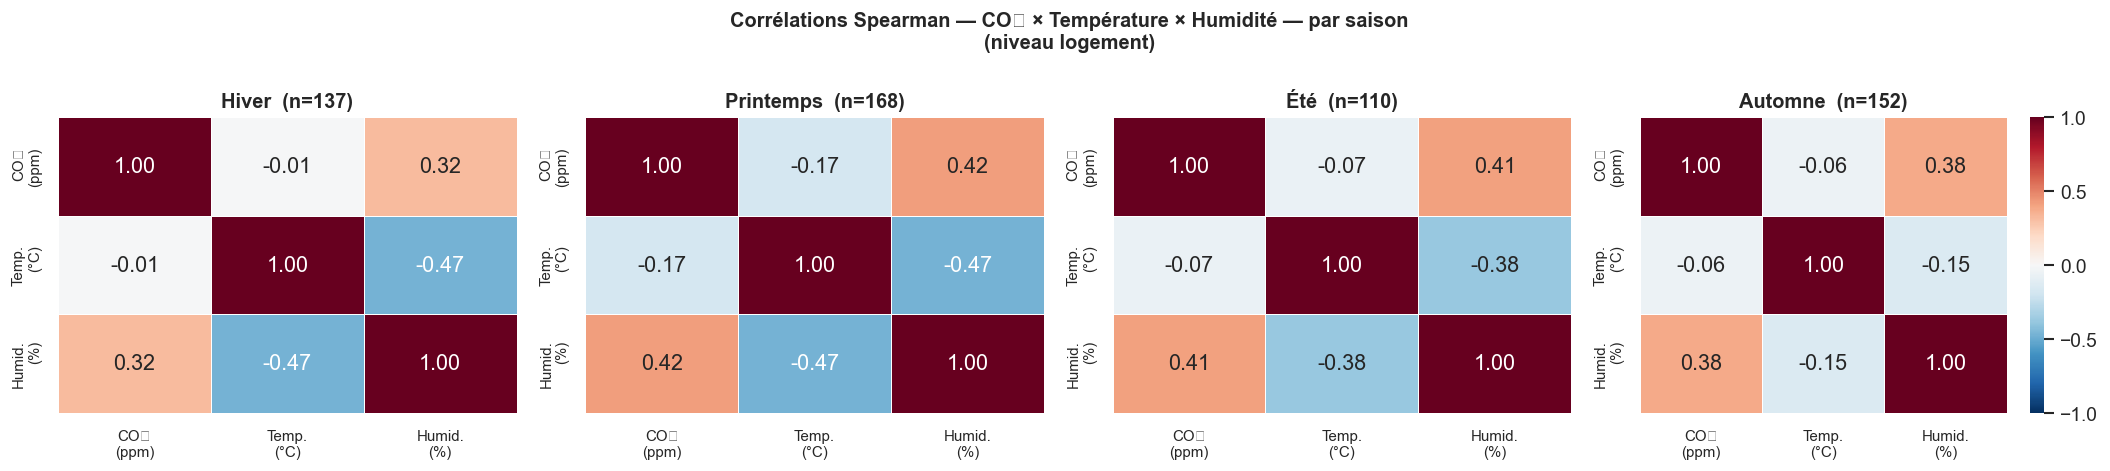

In [11]:
from scipy.stats import spearmanr

df_phys = (log[['CODELIEU', 'zone_climatique', 'saison']]
    .merge(co2_e.groupby('CODELIEU')['VALEUR'].mean().rename('CO2'),         on='CODELIEU', how='left')
    .merge(confort_e.groupby('CODELIEU')['VALEUR_TPT'].mean().rename('TPT'), on='CODELIEU', how='left')
    .merge(confort_e.groupby('CODELIEU')['VALEUR_HRE'].mean().rename('HRE'), on='CODELIEU', how='left')
)

phys_vars   = ['CO2', 'TPT', 'HRE']
tick_labels = ['CO₂\n(ppm)', 'Temp.\n(°C)', 'Humid.\n(%)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, sais in zip(axes, SAISON_ORDER):
    sub = df_phys[df_phys['saison'] == sais]

    r_mat = pd.DataFrame(np.nan, index=phys_vars, columns=phys_vars)
    annot = pd.DataFrame('',     index=phys_vars, columns=phys_vars)

    for x in phys_vars:
        for y in phys_vars:
            if x == y:
                r_mat.loc[x, y] = 1.0
                annot.loc[x, y] = '1.00'
            else:
                pair = sub[[x, y]].dropna()
                if len(pair) >= 10:
                    r, p = spearmanr(pair[x], pair[y])
                    r_mat.loc[x, y] = r
                    annot.loc[x, y] = f'{r:.2f}'

    sns.heatmap(r_mat.astype(float), annot=annot, fmt='',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 13},
                xticklabels=tick_labels, yticklabels=tick_labels,
                cbar=(ax == axes[-1]))
    ax.set_title(f'{sais}  (n={len(sub)})', fontweight='bold', fontsize=12)
    ax.tick_params(labelsize=9)

plt.suptitle(
    'Corrélations Spearman — CO₂ × Température × Humidité — par saison\n'
    '(niveau logement)',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Analyse temporelle

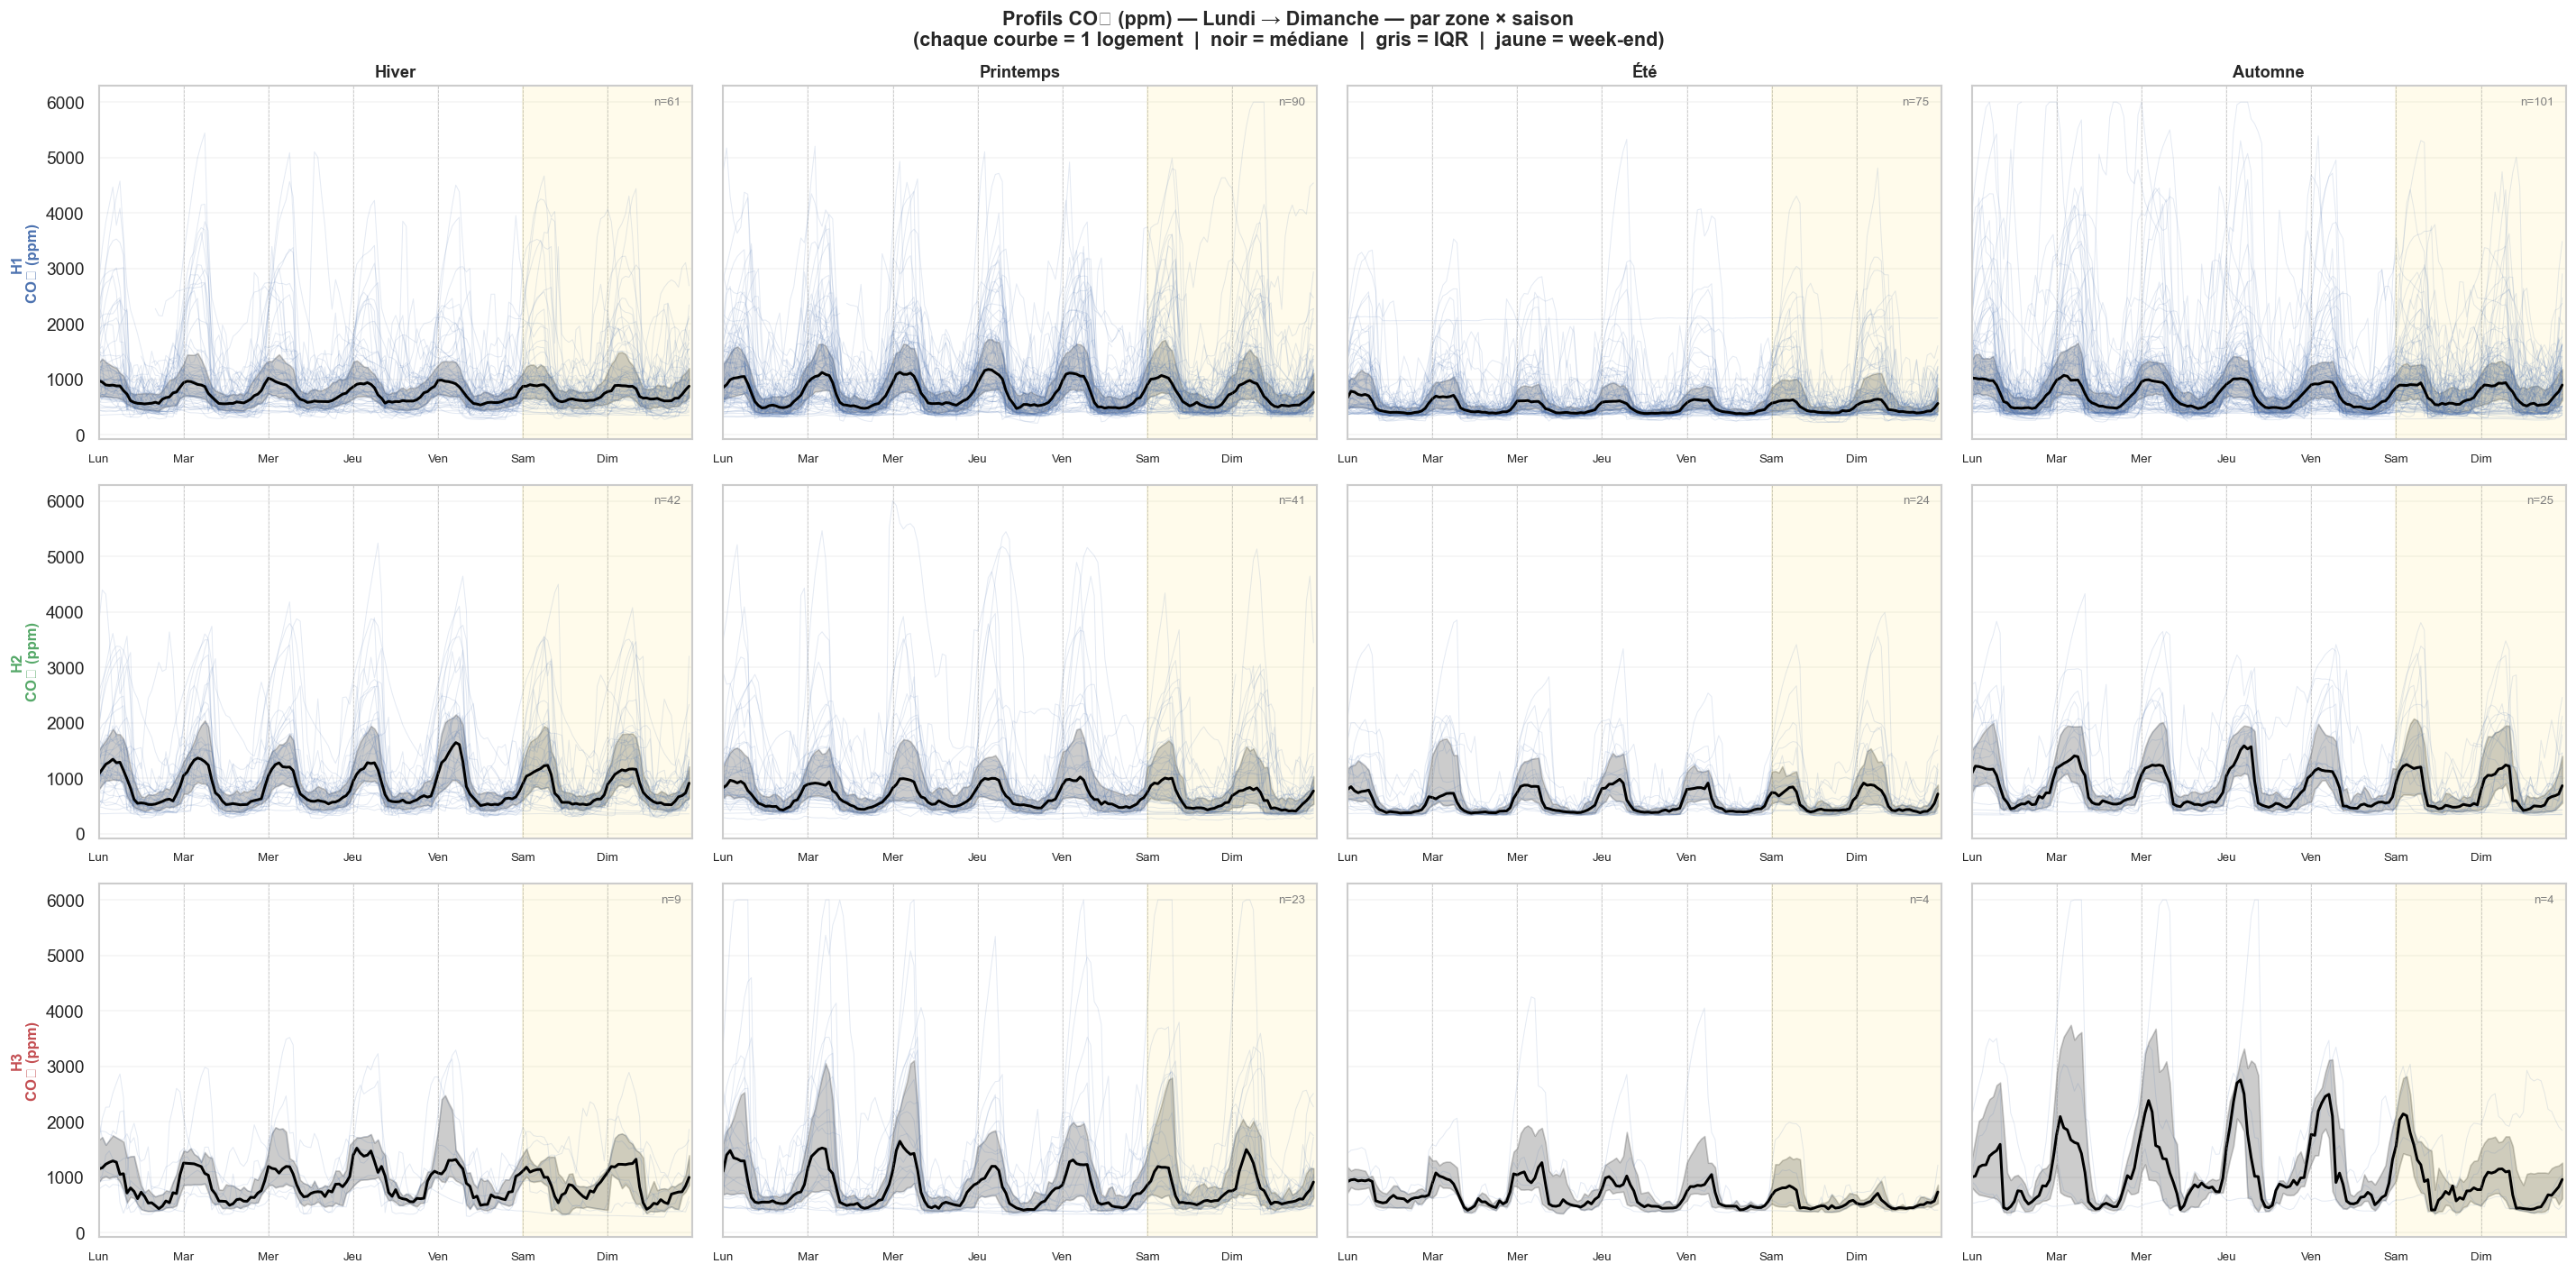

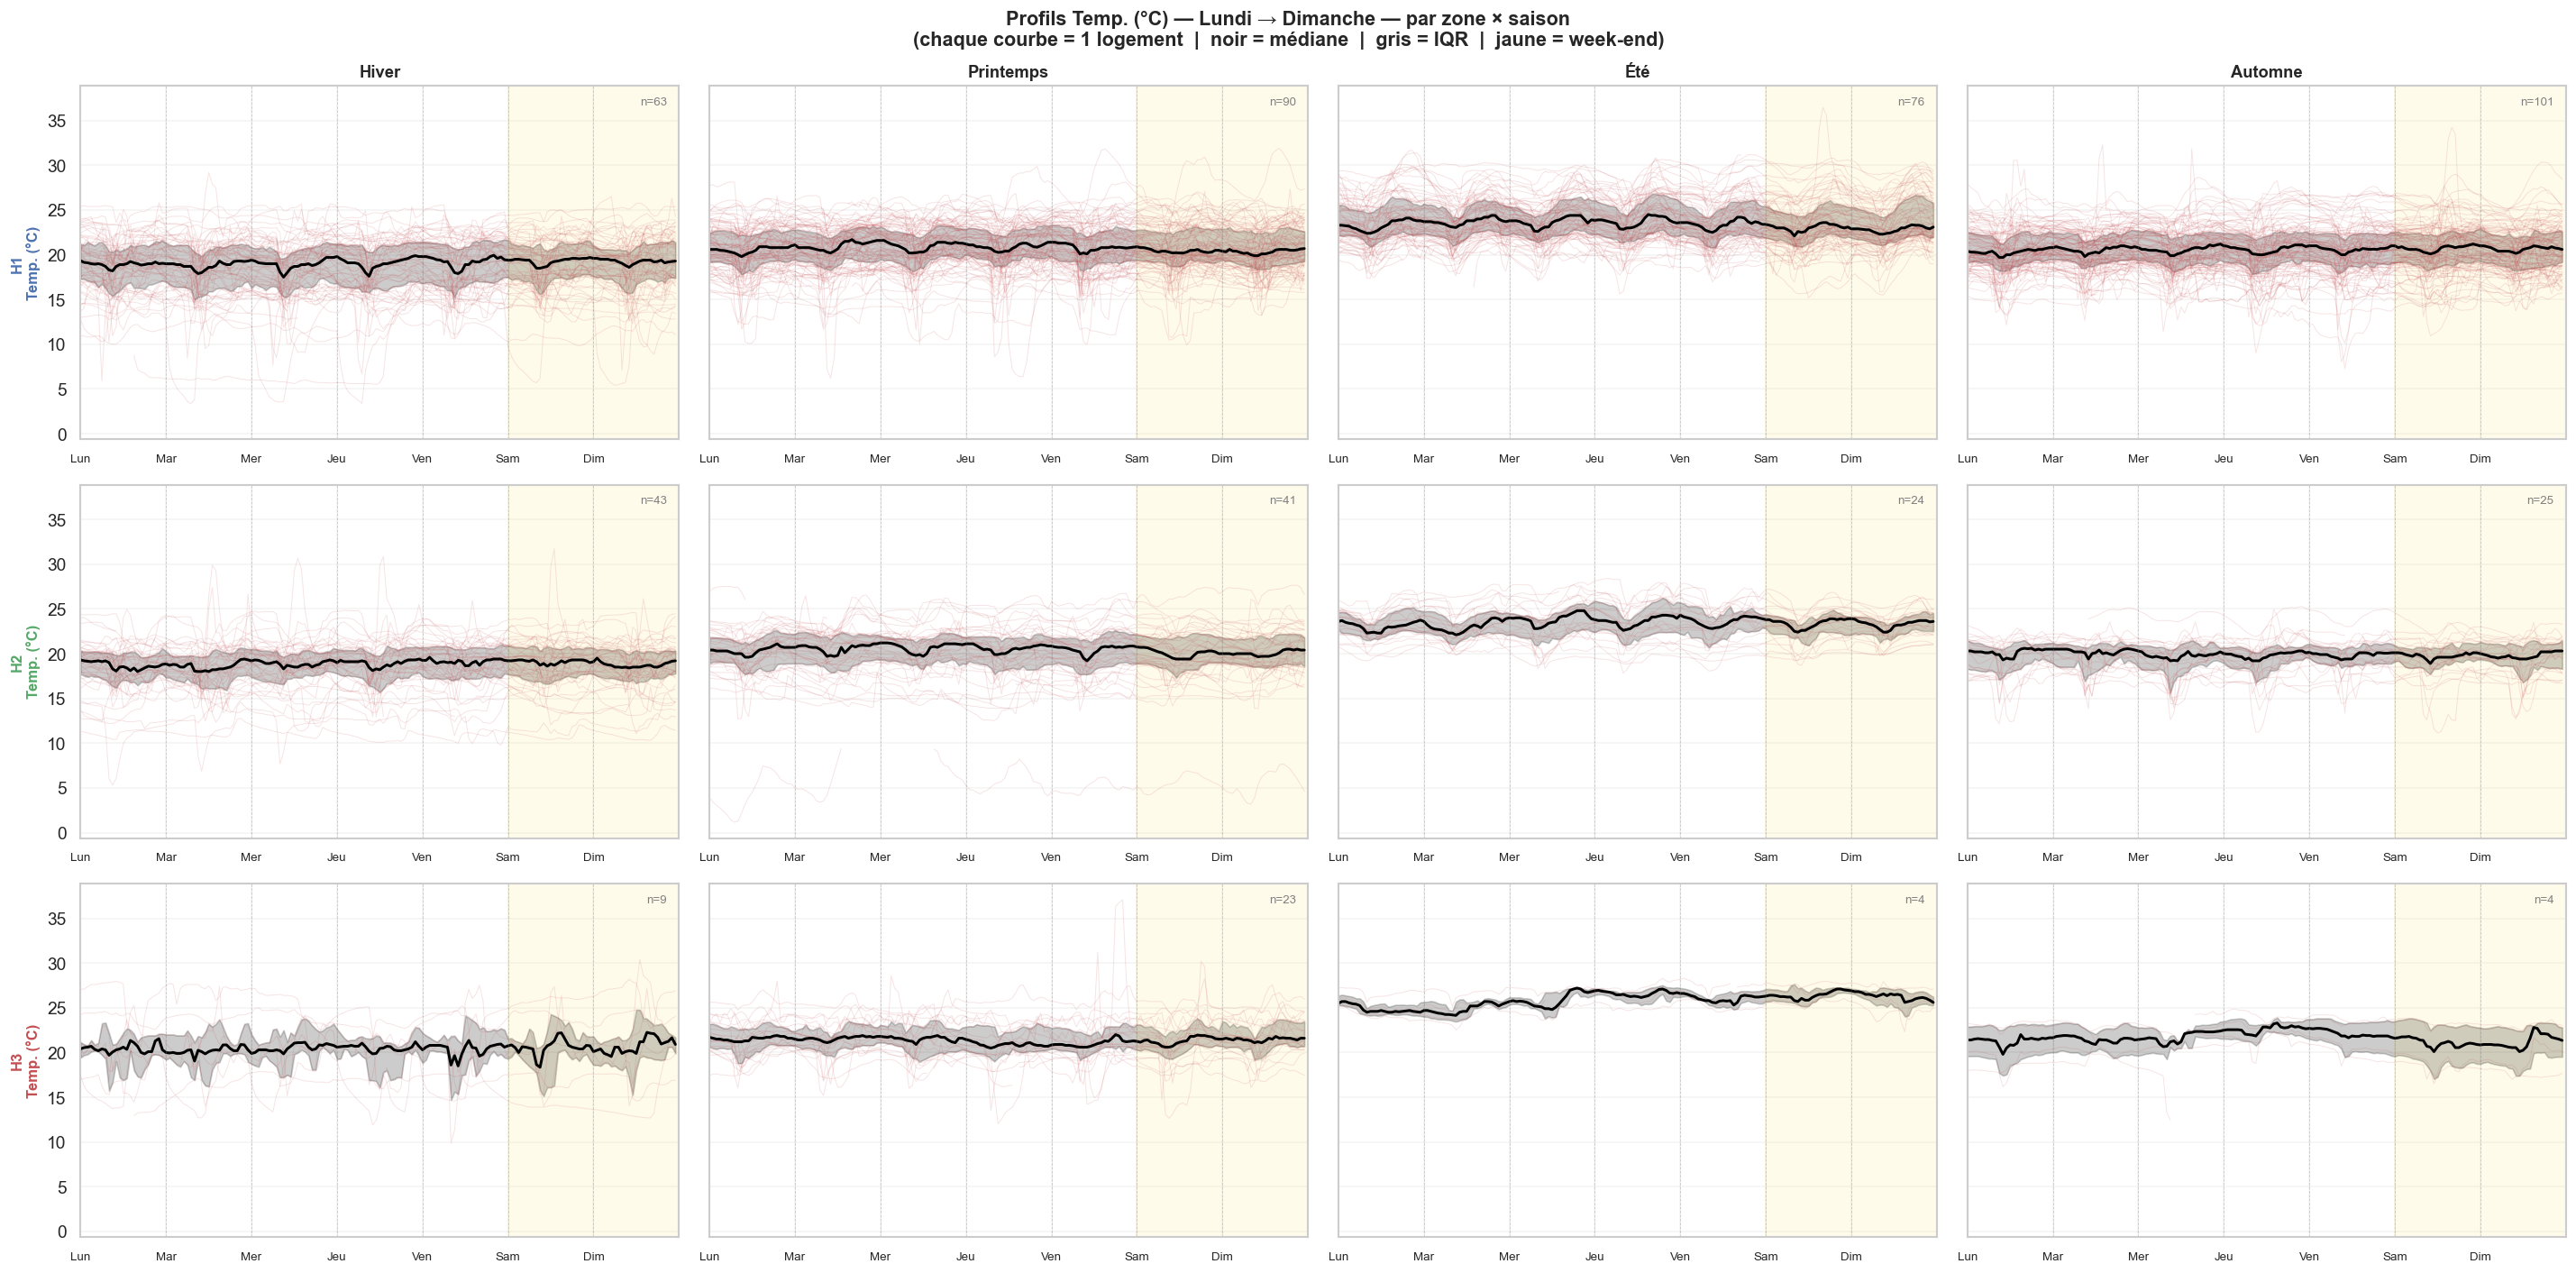

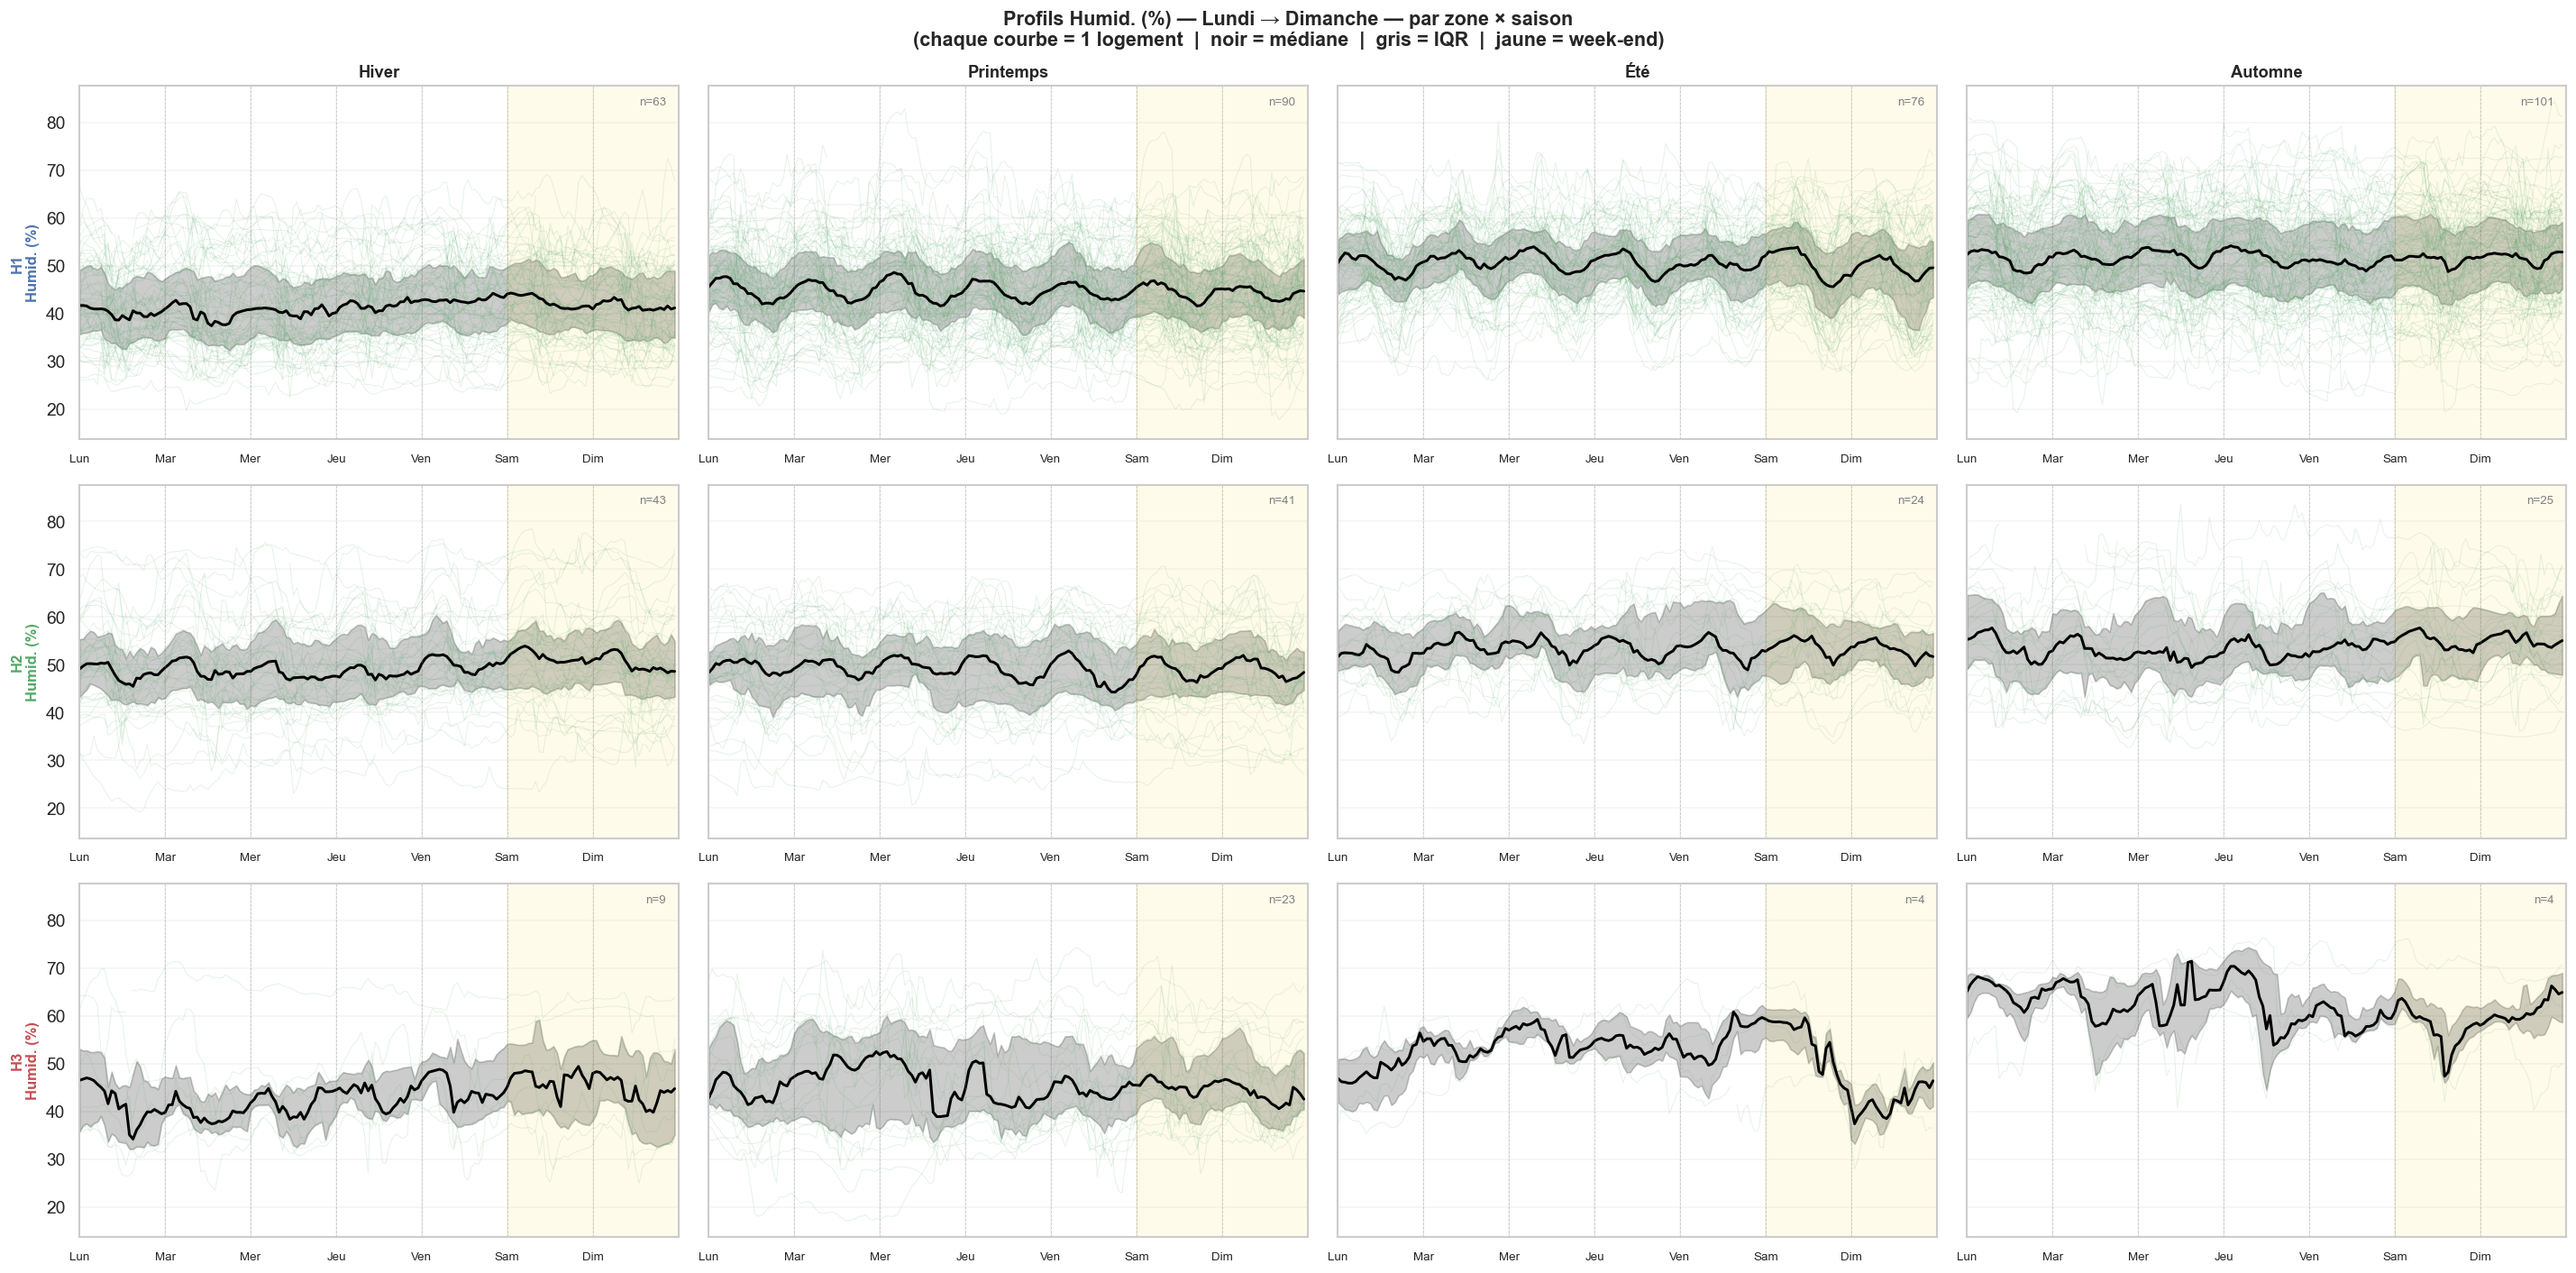

In [12]:
co2_e['jour_sem']    = co2_e['DATE_HEURE'].dt.dayofweek
co2_e['heure']       = co2_e['DATE_HEURE'].dt.hour
co2_e['cal_pos']     = co2_e['jour_sem'] * 24 + co2_e['heure']
confort_e['jour_sem'] = confort_e['DATE_HEURE'].dt.dayofweek
confort_e['heure']    = confort_e['DATE_HEURE'].dt.hour
confort_e['cal_pos']  = confort_e['jour_sem'] * 24 + confort_e['heure']

tick_pos    = [i * 24 for i in range(8)]
tick_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim','']

MESURES = [
    (co2_e,     'VALEUR',     'CO₂ (ppm)',  '#4C72B0'),
    (confort_e, 'VALEUR_TPT', 'Temp. (°C)', '#C44E52'),
    (confort_e, 'VALEUR_HRE', 'Humid. (%)', '#55A868'),
]

for df_m, col_m, label_m, color_m in MESURES:
    fig, axes = plt.subplots(3, 4, figsize=(24, 12), sharey=True)

    for row, zone in enumerate(ZONE_ORDER):
        for col, sais in enumerate(SAISON_ORDER):
            ax  = axes[row, col]
            sub = df_m[(df_m['zone_climatique'] == zone) & (df_m['saison'] == sais)]
            n   = sub['CODELIEU'].nunique()

            if n == 0:
                ax.axis('off'); continue

            profils = (sub.groupby(['CODELIEU', 'cal_pos'])[col_m]
                       .mean().unstack('cal_pos'))
            for _, row_p in profils.iterrows():
                ax.plot(row_p.index, row_p.values,
                        color=color_m, alpha=0.15, lw=0.6)

            med = sub.groupby('cal_pos')[col_m].median()
            q1  = sub.groupby('cal_pos')[col_m].quantile(0.25)
            q3  = sub.groupby('cal_pos')[col_m].quantile(0.75)
            ax.plot(med.index, med.values, color='black', lw=1.8)
            ax.fill_between(med.index, q1, q3, alpha=0.20, color='black')

            ax.axvspan(120, 168, color='#FFD700', alpha=0.08)
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.set_xlim(0, 168)
            for xv in tick_pos[1:-1]:
                ax.axvline(xv, color='grey', lw=0.5, ls='--', alpha=0.4)
            ax.grid(True, alpha=0.2)

            if row == 0:
                ax.set_title(sais, fontweight='bold', fontsize=11)
            if col == 0:
                ax.set_ylabel(f'{zone}\n{label_m}', fontsize=10,
                              fontweight='bold', color=ZONE_COLORS[zone])
            ax.text(0.98, 0.97, f'n={n}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, color='grey')

    plt.suptitle(f'Profils {label_m} — Lundi → Dimanche — par zone × saison\n'
                 '(chaque courbe = 1 logement  |  noir = médiane  |  gris = IQR  |  jaune = week-end)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

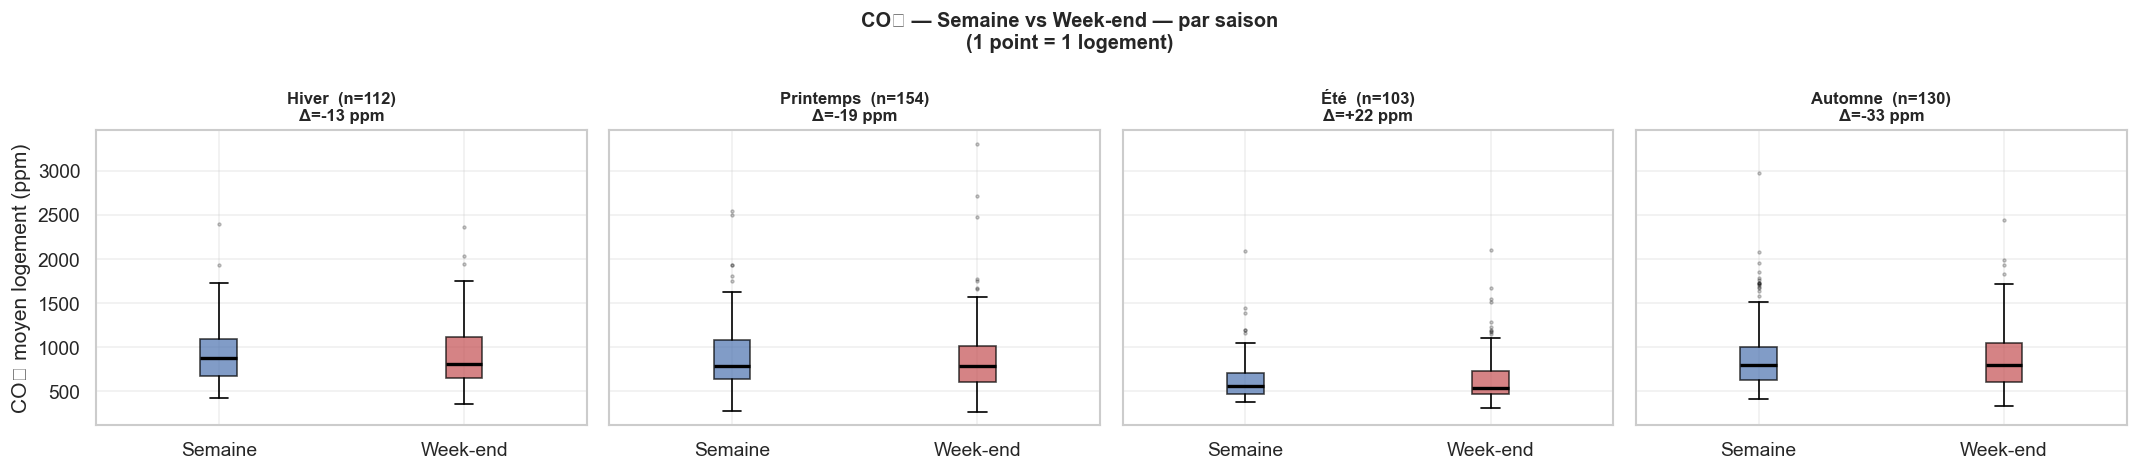


Saison          Moy Sem     Moy WE        Δ
──────────────────────────────────────────
Hiver             923.5      910.2    -13.3
Printemps         894.3      875.5    -18.8
Été               631.7      653.6    +21.9
Automne           906.5      873.6    -32.8


In [13]:
co2_e['we'] = co2_e['jour_sem'] >= 5

co2_we = (co2_e.groupby(['CODELIEU', 'we'])['VALEUR']
          .mean().unstack('we')
          .rename(columns={False: 'Semaine', True: 'Week-end'})
          .dropna())
co2_we = co2_we.merge(log[['CODELIEU','saison','zone_climatique']], on='CODELIEU')

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, sais in zip(axes, SAISON_ORDER):
    sub  = co2_we[co2_we['saison'] == sais]
    bp   = ax.boxplot([sub['Semaine'], sub['Week-end']],
                      labels=['Semaine', 'Week-end'],
                      patch_artist=True,
                      medianprops=dict(color='black', lw=2),
                      flierprops=dict(marker='.', markersize=3, alpha=0.3))
    bp['boxes'][0].set_facecolor('#4C72B0'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#C44E52'); bp['boxes'][1].set_alpha(0.7)

    delta = sub['Week-end'].mean() - sub['Semaine'].mean()
    ax.set_title(f'{sais}  (n={len(sub)})\nΔ={delta:+.0f} ppm',
                 fontweight='bold', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('CO₂ moyen logement (ppm)')
    ax.grid(True, alpha=0.3)

plt.suptitle('CO₂ — Semaine vs Week-end — par saison\n(1 point = 1 logement)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n{'Saison':<12} {'Moy Sem':>10} {'Moy WE':>10} {'Δ':>8}")
print("─" * 42)
for sais in SAISON_ORDER:
    sub = co2_we[co2_we['saison'] == sais]
    d   = sub['Week-end'].mean() - sub['Semaine'].mean()
    print(f"{sais:<12} {sub['Semaine'].mean():>10.1f} {sub['Week-end'].mean():>10.1f} {d:>+8.1f}")

In [14]:
def _plot_pca_clusters(ax, x2d, lbls, n_clusters, title, ev_ratio):
    ax.scatter(x2d[:, 0], x2d[:, 1], c=lbls, cmap='tab10', s=40, alpha=0.7)
    for c in range(n_clusters):
        mask = lbls == c
        if mask.sum() == 0: continue
        cx, cy = x2d[mask, 0].mean(), x2d[mask, 1].mean()
        ax.annotate(f'C{c}', (cx, cy), fontsize=9, fontweight='bold', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='grey'))
    ax.set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}%)')
    ax.set_title(title, fontweight='bold'); ax.grid(True, alpha=0.2)

## 4. Clustering — Signatures ACF

In [15]:
from statsmodels.tsa.stattools import acf

LAGS = [1, 6, 12, 72, 144, 288, 432]
MIN_POINTS = max(LAGS) + 50

MESURES_ACF = [
    (co2_e,     'VALEUR',     'co2'),
    (confort_e, 'VALEUR_TPT', 'tpt'),
    (confort_e, 'VALEUR_HRE', 'hre'),
]

coverage = pd.DataFrame({'CODELIEU': log['CODELIEU']})
for df_m, col, prefix in MESURES_ACF:
    n = df_m.groupby('CODELIEU')[col].count().rename(f'n_{prefix}')
    coverage = coverage.merge(n, on='CODELIEU', how='left')

coverage = coverage.fillna(0).astype({'n_co2': int, 'n_tpt': int, 'n_hre': int})
coverage['n_min'] = coverage[['n_co2','n_tpt','n_hre']].min(axis=1)

codelieux_valides = coverage[coverage['n_min'] > MIN_POINTS]['CODELIEU'].tolist()
print(f'Lag max : {max(LAGS)} x 10 min = {max(LAGS)*10//60}h  |  Seuil minimum : {MIN_POINTS} points')
print(f'Logements retenus : {len(codelieux_valides)} / {len(log)}  ({100*len(codelieux_valides)/len(log):.1f}%)')

Lag max : 432 x 10 min = 72h  |  Seuil minimum : 482 points
Logements retenus : 497 / 567  (87.7%)


In [16]:
rows = []
for codelieu in codelieux_valides:
    row = {'CODELIEU': codelieu}
    for df_m, col, prefix in MESURES_ACF:
        ts = (df_m[df_m['CODELIEU'] == codelieu]
              .sort_values('DATE_HEURE')[col]
              .dropna().values)
        try:
            vals = acf(ts, nlags=max(LAGS), fft=True)
            for lag in LAGS:
                row[f'{prefix}_acf_{lag}'] = vals[lag]
        except Exception:
            for lag in LAGS:
                row[f'{prefix}_acf_{lag}'] = np.nan
    rows.append(row)

df_acf      = pd.DataFrame(rows).set_index('CODELIEU')
df_acf_full = df_acf.copy()

print(f'\nShape : {df_acf.shape}  ({len(LAGS)} lags x 3 signaux = {len(LAGS)*3} features)')
display(df_acf.head(3).round(3))


Shape : (497, 21)  (7 lags x 3 signaux = 21 features)


,co2_acf_1,co2_acf_6,co2_acf_12,co2_acf_72,co2_acf_144,co2_acf_288,co2_acf_432,tpt_acf_1,tpt_acf_6,tpt_acf_12,tpt_acf_72,tpt_acf_144,tpt_acf_288,tpt_acf_432,hre_acf_1,hre_acf_6,hre_acf_12,hre_acf_72,hre_acf_144,hre_acf_288,hre_acf_432
CODELIEU,,,,,,,,,,,,,,,,,,,,,
01-M001,0.94,0.60,0.29,0.15,0.25,0.32,0.26,0.99,0.92,0.79,0.13,0.55,0.31,0.15,0.99,0.89,0.75,-0.06,-0.39,0.01,0.01
01-M002,0.99,0.87,0.69,-0.52,0.70,0.52,0.45,0.99,0.76,0.41,-0.17,0.47,0.27,0.23,0.99,0.89,0.78,0.00,0.47,0.23,0.01
01-M004,0.98,0.81,0.60,-0.25,0.26,0.06,0.15,0.99,0.88,0.74,0.06,0.33,0.08,0.09,0.99,0.91,0.82,0.34,0.21,-0.17,-0.14


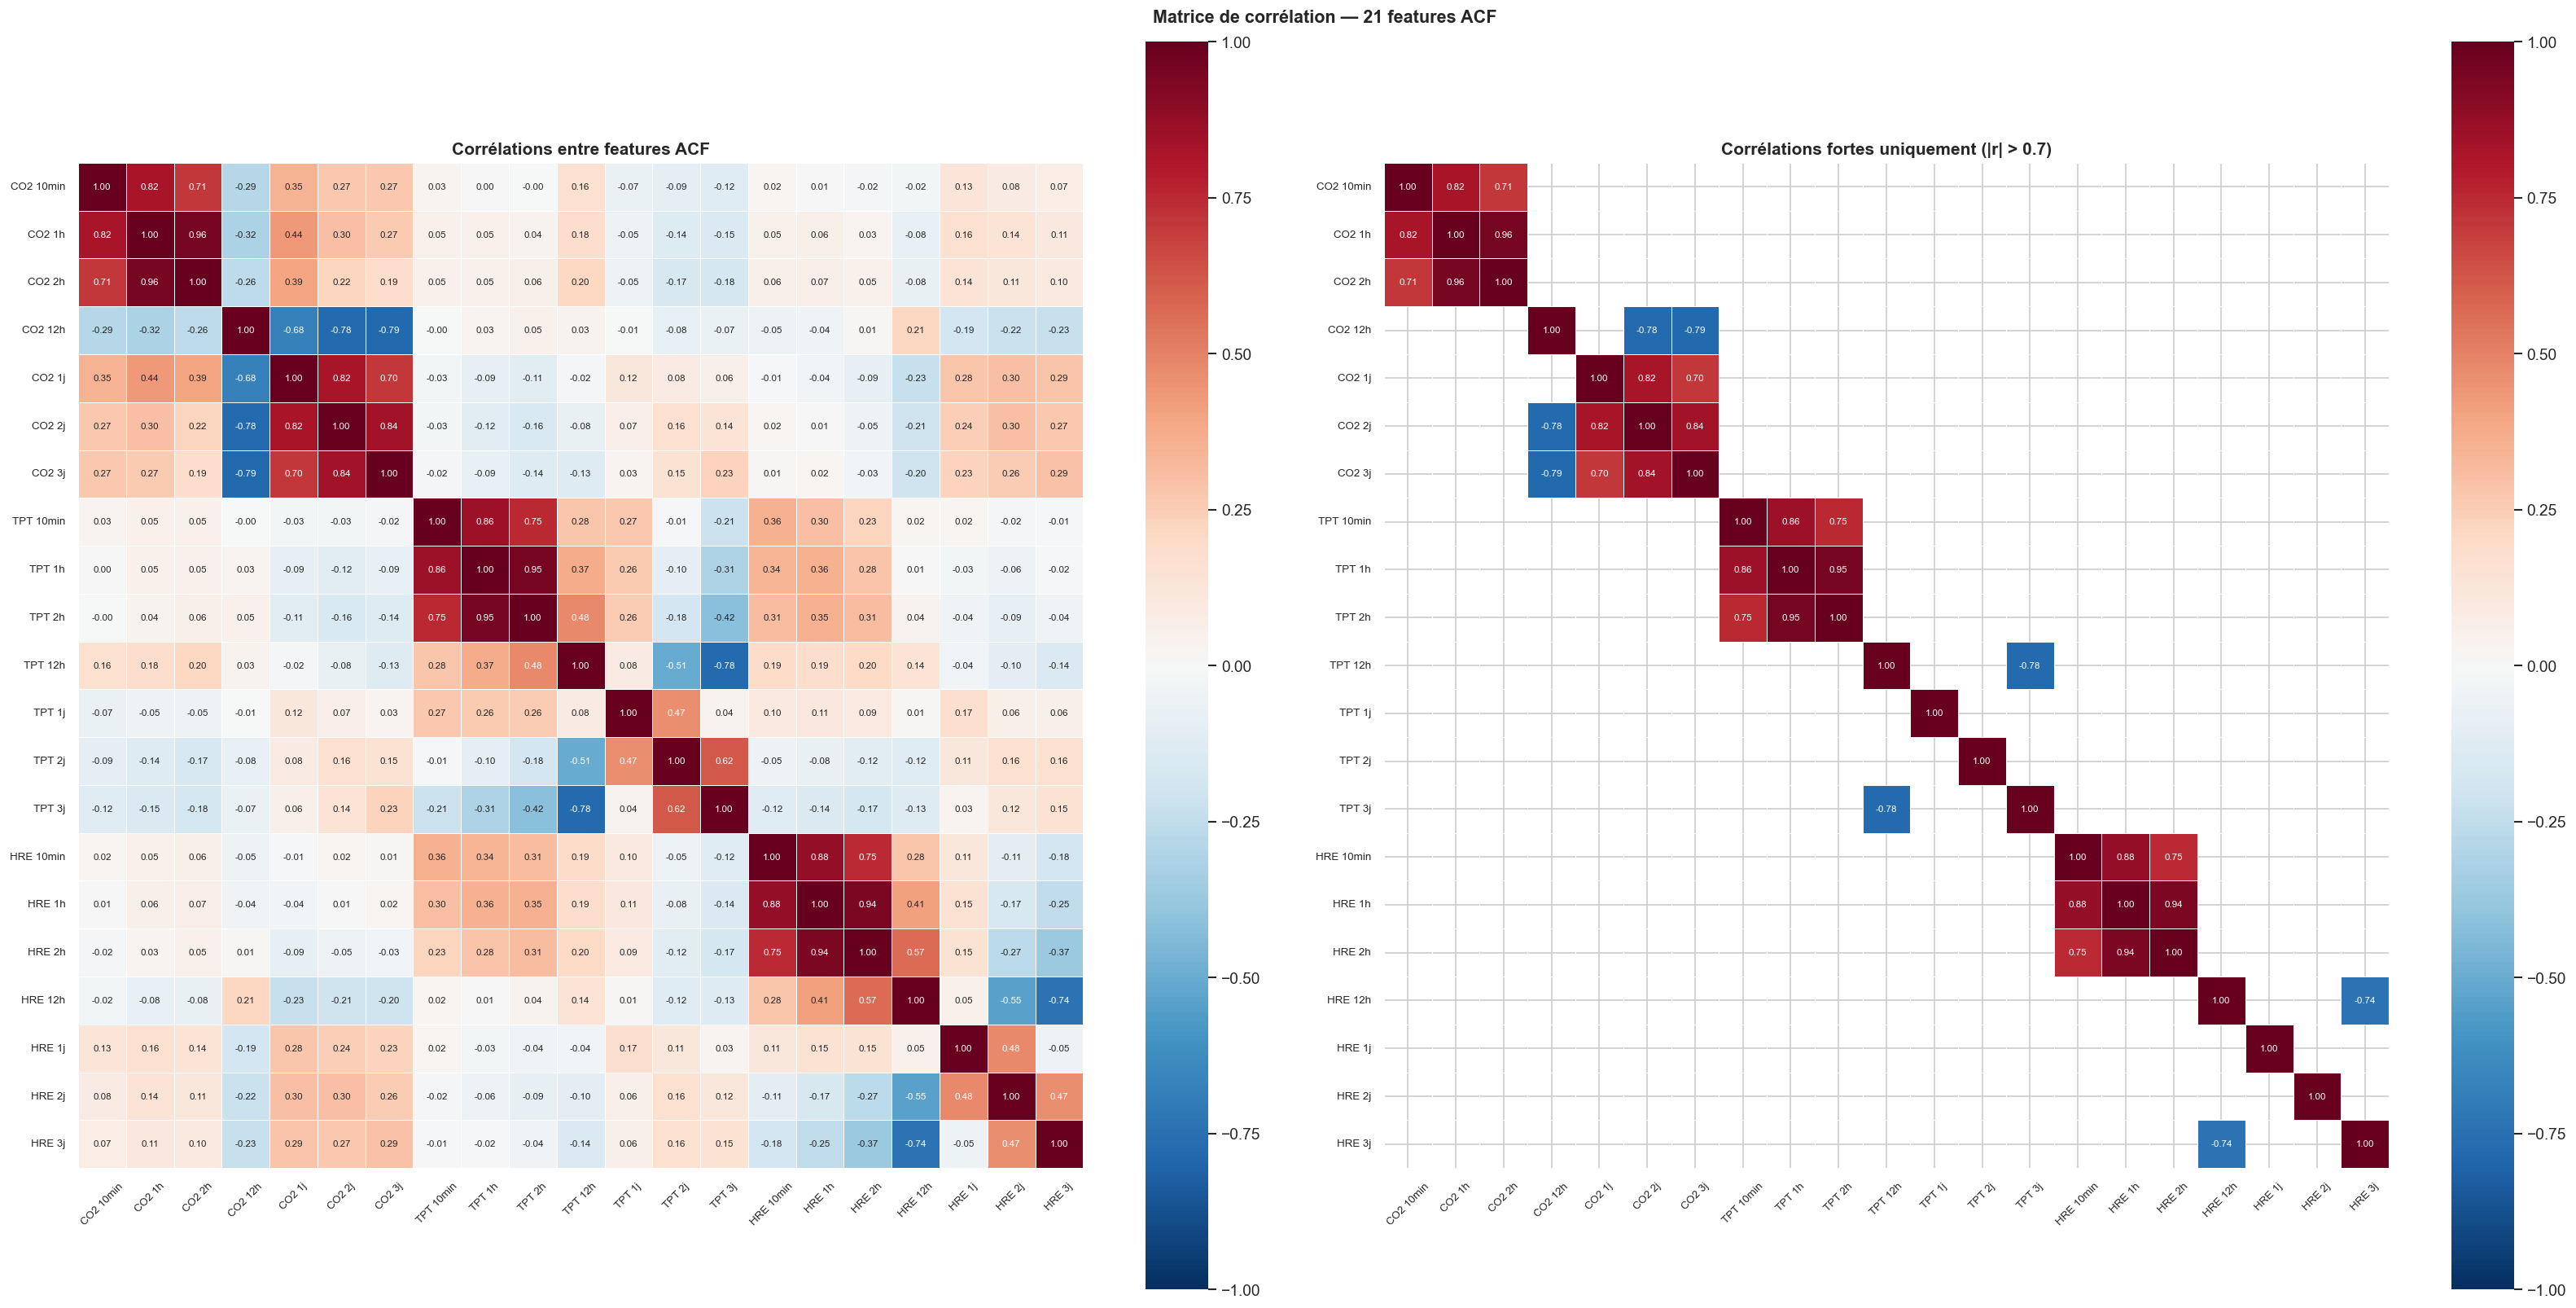

In [17]:
def _col_to_label(col):
    prefix, lag = col.split('_acf_')
    m = int(lag) * 10
    if m < 60:     ts = f'{m}min'
    elif m < 1440: ts = f'{m//60}h'
    else:          ts = f'{m//1440}j'
    return f'{prefix.upper()} {ts}'

col_labels = [_col_to_label(c) for c in df_acf_full.columns]
corr = df_acf_full.corr()
n    = len(col_labels)
size = max(12, n * 0.65)

fig, axes = plt.subplots(1, 2, figsize=(size * 2, size))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=col_labels, yticklabels=col_labels,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, square=True, ax=axes[0])
axes[0].set_title('Corrélations entre features ACF', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

mask = corr.abs() < 0.7
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=col_labels, yticklabels=col_labels,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            mask=mask, linewidths=0.3, square=True, ax=axes[1])
axes[1].set_title('Corrélations fortes uniquement (|r| > 0.7)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(f'Matrice de corrélation — {n} features ACF', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

In [18]:
LAGS = [1, 72, 144]

cols_retenus = [f'{p}_acf_{l}' for p in ['co2', 'tpt', 'hre'] for l in LAGS]
df_acf = df_acf_full[cols_retenus]
X      = StandardScaler().fit_transform(df_acf)

print(f'Features retenues : {df_acf.shape[1]}  ({len(LAGS)} lags x 3 signaux)')
print(f'Logements         : {df_acf.shape[0]}')
print(f'\nColonnes : {df_acf.columns.tolist()}')

Features retenues : 9  (3 lags x 3 signaux)
Logements         : 497

Colonnes : ['co2_acf_1', 'co2_acf_72', 'co2_acf_144', 'tpt_acf_1', 'tpt_acf_72', 'tpt_acf_144', 'hre_acf_1', 'hre_acf_72', 'hre_acf_144']


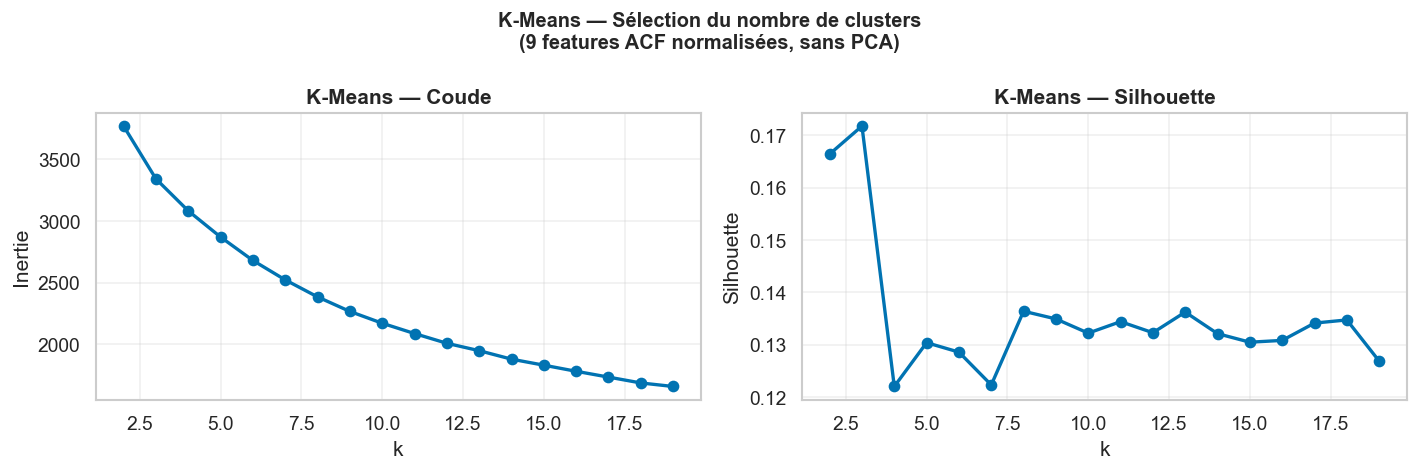

K-Means silhouette max : k=3


In [19]:
from sklearn.metrics import silhouette_score

k_range  = range(2, 20)
inertias = []
sil_km   = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=50)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_km.append(silhouette_score(X, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'bo-', lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie')
axes[0].set_title('K-Means — Coude', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[1].plot(list(k_range), sil_km, 'bo-', lw=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('K-Means — Silhouette', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.suptitle('K-Means — Sélection du nombre de clusters\n(9 features ACF normalisées, sans PCA)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

k_km = list(k_range)[sil_km.index(max(sil_km))]
print(f'K-Means silhouette max : k={k_km}')

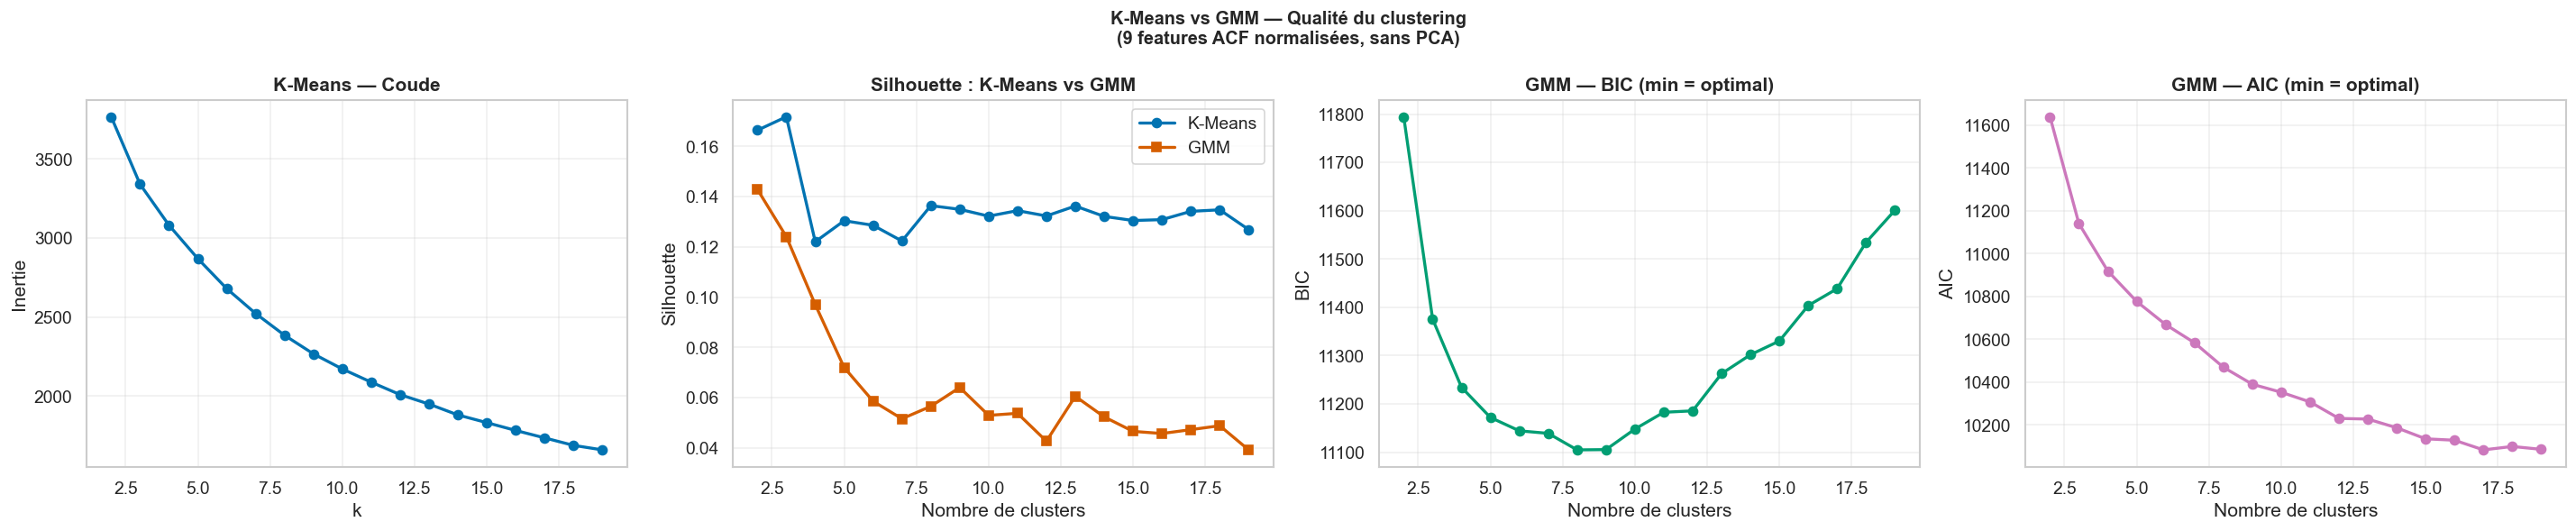

K-Means silhouette max : k=3
GMM BIC minimum        : k=8


In [20]:
from sklearn.mixture import GaussianMixture

k_range_gmm = range(2, 20)
bic_scores, aic_scores, sil_gmm = [], [], []
gmm_models = {}

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42, n_init=50)
    lbl = gmm.fit_predict(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))
    sil_gmm.append(silhouette_score(X, lbl))
    gmm_models[k] = gmm

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
axes[0].plot(list(k_range), inertias, 'bo-', lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie')
axes[0].set_title('K-Means — Coude', fontweight='bold'); axes[0].grid(True, alpha=0.3)
axes[1].plot(list(k_range),     sil_km,  'bo-', lw=2, label='K-Means')
axes[1].plot(list(k_range_gmm), sil_gmm, 'rs-', lw=2, label='GMM')
axes[1].set_xlabel('Nombre de clusters'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette : K-Means vs GMM', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(list(k_range_gmm), bic_scores, 'go-', lw=2)
axes[2].set_xlabel('Nombre de clusters'); axes[2].set_ylabel('BIC')
axes[2].set_title('GMM — BIC (min = optimal)', fontweight='bold'); axes[2].grid(True, alpha=0.3)
axes[3].plot(list(k_range_gmm), aic_scores, 'mo-', lw=2)
axes[3].set_xlabel('Nombre de clusters'); axes[3].set_ylabel('AIC')
axes[3].set_title('GMM — AIC (min = optimal)', fontweight='bold'); axes[3].grid(True, alpha=0.3)
plt.suptitle('K-Means vs GMM — Qualité du clustering\n(9 features ACF normalisées, sans PCA)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

k_km  = list(k_range)[sil_km.index(max(sil_km))]
k_bic = list(k_range_gmm)[bic_scores.index(min(bic_scores))]
print(f'K-Means silhouette max : k={k_km}')
print(f'GMM BIC minimum        : k={k_bic}')

gmm_final = gmm_models[k_bic]
labels    = gmm_final.predict(X)

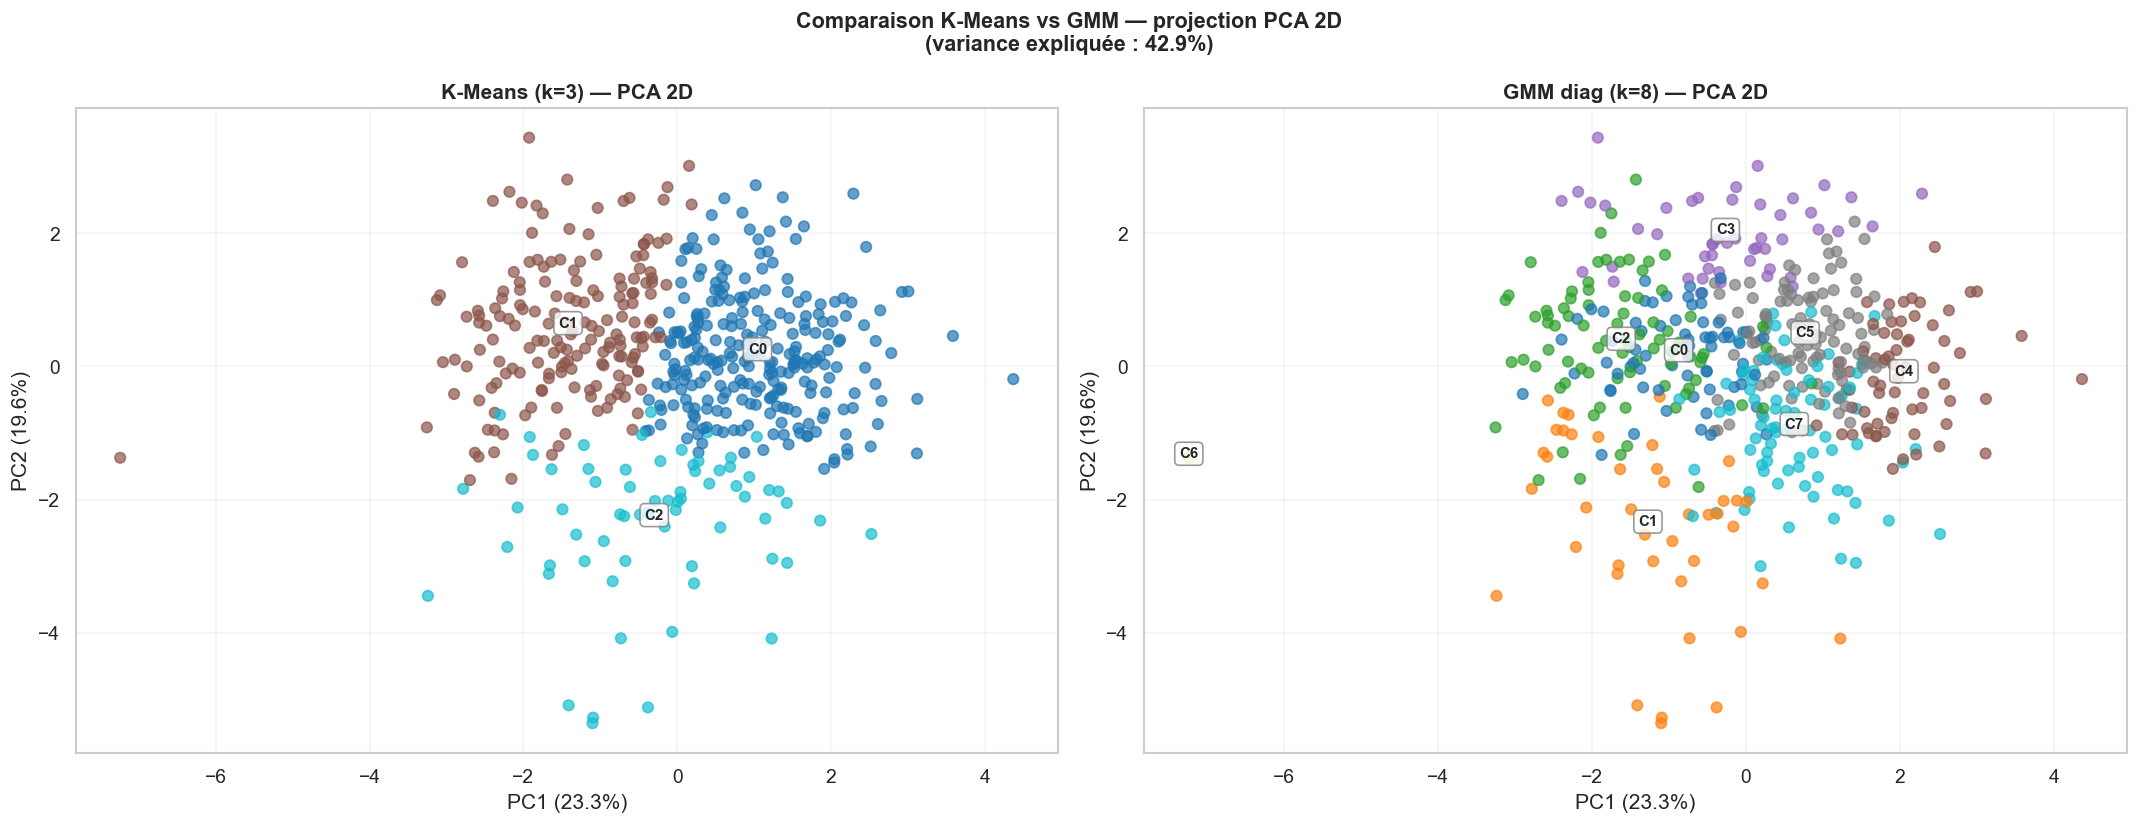

In [21]:
pca2d   = PCA(n_components=2)
X_2d    = pca2d.fit_transform(X)
var_exp = sum(pca2d.explained_variance_ratio_) * 100

km_final  = KMeans(n_clusters=k_km, random_state=42, n_init=50)
labels_km = km_final.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
_plot_pca_clusters(axes[0], X_2d, labels_km, k_km,  f'K-Means (k={k_km}) — PCA 2D', pca2d.explained_variance_ratio_)
_plot_pca_clusters(axes[1], X_2d, labels,    k_bic, f'GMM diag (k={k_bic}) — PCA 2D', pca2d.explained_variance_ratio_)
plt.suptitle(f'Comparaison K-Means vs GMM — projection PCA 2D\n(variance expliquée : {var_exp:.1f}%)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

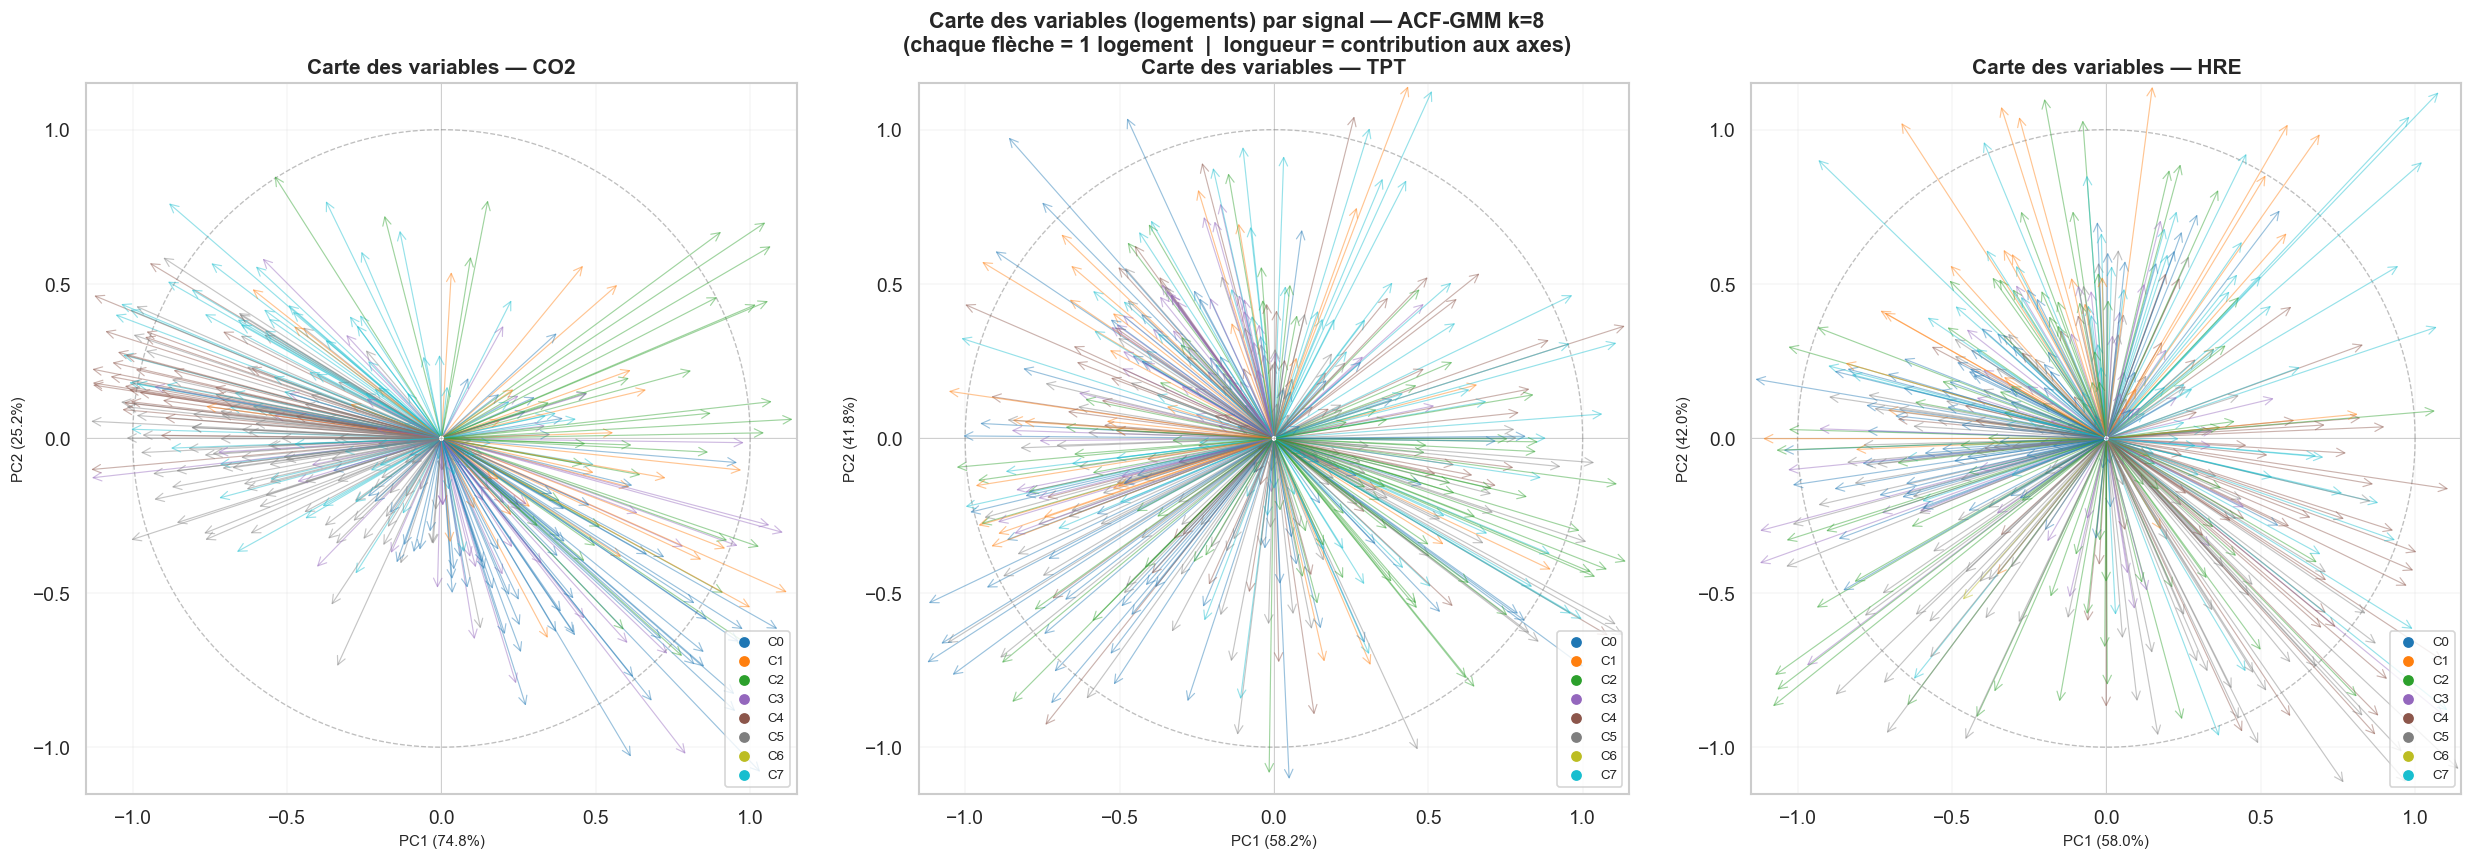

In [22]:
SIGNALS_ACF = [
    ('CO2', [c for c in df_acf.columns if c.startswith('co2_')]),
    ('TPT', [c for c in df_acf.columns if c.startswith('tpt_')]),
    ('HRE', [c for c in df_acf.columns if c.startswith('hre_')]),
]
k_clusters_s8 = sorted(set(labels))
colors_s8     = {c: plt.cm.tab10(c / max(k_clusters_s8 + [1])) for c in k_clusters_s8}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, cols) in zip(axes, SIGNALS_ACF):
    X_s   = StandardScaler().fit_transform(df_acf[cols])
    pca_t = PCA(n_components=2).fit(X_s.T)
    coords = pca_t.components_.T * np.sqrt(pca_t.explained_variance_)

    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color='grey', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(0, color='grey', lw=0.5, alpha=0.4)
    ax.axvline(0, color='grey', lw=0.5, alpha=0.4)

    for j, lbl in enumerate(labels):
        x, y = coords[j]
        ax.annotate('', xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors_s8[lbl], lw=0.7, alpha=0.45))

    for c in k_clusters_s8:
        ax.scatter([], [], color=colors_s8[c], label=f'C{c}', s=30)

    ev = pca_t.explained_variance_ratio_
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=9)
    ax.set_title(f'Carte des variables — {name}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.15)

plt.suptitle(f'Carte des variables (logements) par signal — ACF-GMM k={k_bic}\n'
             '(chaque flèche = 1 logement  |  longueur = contribution aux axes)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
counts = pd.Series(labels).value_counts().sort_index()
total  = len(labels)

df_acf_labeled = df_acf.copy()
df_acf_labeled['cluster'] = labels

rename = {
    'co2_acf_1':   'CO2 10min', 'co2_acf_72':  'CO2 12h',  'co2_acf_144': 'CO2 24h',
    'tpt_acf_1':   'TPT 10min', 'tpt_acf_72':  'TPT 12h',  'tpt_acf_144': 'TPT 24h',
    'hre_acf_1':   'HRE 10min', 'hre_acf_72':  'HRE 12h',  'hre_acf_144': 'HRE 24h',
}
acf_cols = list(rename.keys())

means = df_acf_labeled.groupby('cluster')[acf_cols].mean().rename(columns=rename)
stds  = df_acf_labeled.groupby('cluster')[acf_cols].std().rename(columns=rename)

display(
    means.rename(index=lambda c: f'C{c}')
    .assign(n=counts.values, pct=(counts.values / total * 100).round(1))
    .pipe(lambda df: df[['n', 'pct'] + list(rename.values())])
    .style
    .format({'n': '{:.0f}', 'pct': '{:.1f}%', **{c: '{:.3f}' for c in rename.values()}})
    .background_gradient(subset=list(rename.values()), cmap='RdYlGn', axis=0)
    .set_caption(f'Carte d\'identité — ACF-GMM k={k_bic}  |  moyenne (μ)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('text-align','left')]},
        {'selector': 'th',      'props': [('font-size','11px'), ('text-align','center')]},
        {'selector': 'td',      'props': [('font-size','11px'), ('text-align','center')]},
    ])
)

display(
    stds.rename(index=lambda c: f'C{c}')
    .style
    .format({c: '{:.3f}' for c in rename.values()})
    .background_gradient(subset=list(rename.values()), cmap='YlOrRd', axis=0)
    .set_caption('Dispersion intra-cluster (σ)  |  rouge = cluster hétérogène')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('text-align','left')]},
        {'selector': 'th',      'props': [('font-size','11px'), ('text-align','center')]},
        {'selector': 'td',      'props': [('font-size','11px'), ('text-align','center')]},
    ])
)

,n,pct,CO2 10min,CO2 12h,CO2 24h,TPT 10min,TPT 12h,TPT 24h,HRE 10min,HRE 12h,HRE 24h
cluster,,,,,,,,,,,
C0,70,14.1%,0.988,-0.199,0.243,0.986,0.091,0.216,0.988,0.410,0.249
C1,42,8.5%,0.976,-0.136,0.272,0.965,0.024,0.194,0.950,0.166,0.132
C2,82,16.5%,0.963,-0.030,0.203,0.992,0.073,0.418,0.984,0.210,0.224
C3,49,9.9%,0.986,-0.220,0.340,0.997,0.591,0.515,0.993,0.394,0.318
C4,66,13.3%,0.992,-0.572,0.706,0.986,0.053,0.370,0.985,0.041,0.450
C5,105,21.1%,0.990,-0.425,0.529,0.992,0.189,0.344,0.988,0.161,0.244
C6,1,0.2%,0.695,0.038,0.040,0.985,-0.522,0.487,0.992,0.126,0.128
C7,82,16.5%,0.981,-0.412,0.529,0.981,-0.038,0.372,0.969,0.137,0.292


,CO2 10min,CO2 12h,CO2 24h,TPT 10min,TPT 12h,TPT 24h,HRE 10min,HRE 12h,HRE 24h
cluster,,,,,,,,,
C0,0.006,0.135,0.160,0.009,0.202,0.172,0.007,0.127,0.142
C1,0.017,0.215,0.177,0.024,0.226,0.177,0.030,0.202,0.196
C2,0.026,0.199,0.152,0.004,0.306,0.181,0.011,0.303,0.207
C3,0.009,0.216,0.199,0.002,0.133,0.138,0.004,0.225,0.217
C4,0.003,0.113,0.061,0.009,0.309,0.181,0.008,0.341,0.142
C5,0.004,0.110,0.104,0.003,0.261,0.197,0.005,0.301,0.184
C6,nan,nan,nan,nan,nan,nan,nan,nan,nan
C7,0.007,0.137,0.125,0.010,0.285,0.155,0.016,0.254,0.167


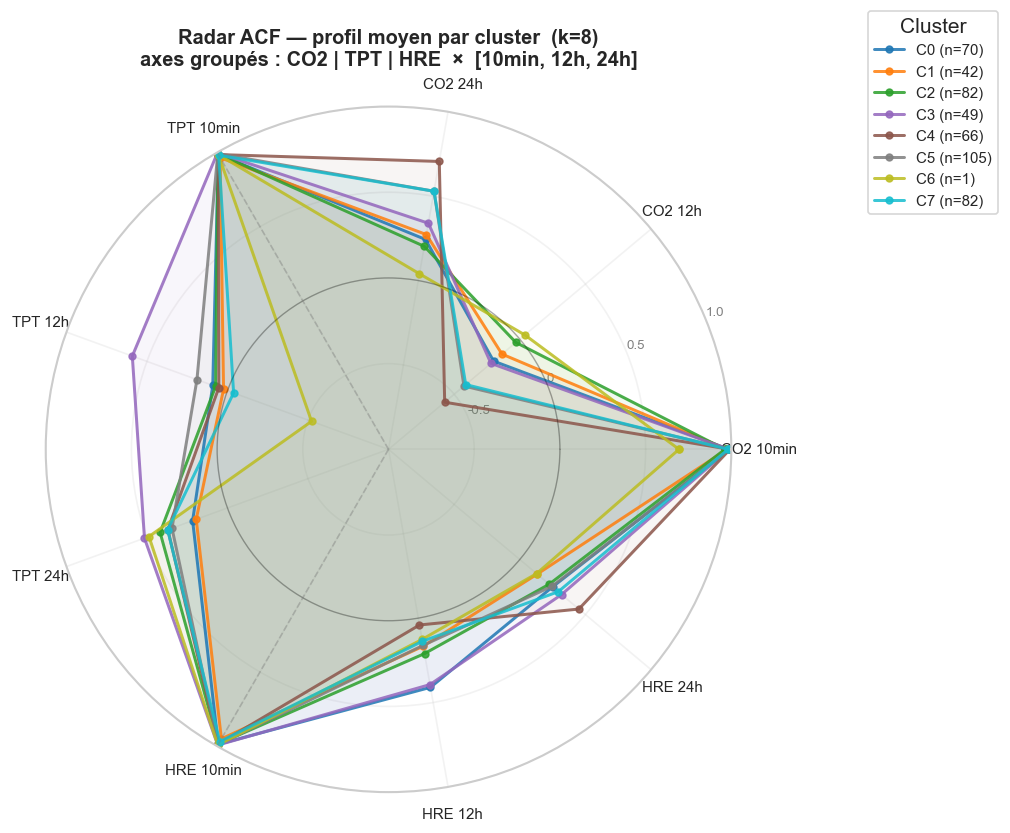

In [24]:
acf_labels = list(rename.values())  # 9 axes dans l'ordre CO2 → TPT → HRE
N      = len(acf_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermeture du polygone

k_list = sorted(set(labels))
cmap   = plt.cm.tab10

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for c in k_list:
    vals  = means.loc[c, acf_labels].tolist()
    vals += vals[:1]
    color = cmap(c / max(k_list + [1]))
    ax.plot(angles, vals, 'o-', lw=1.8, color=color,
            label=f'C{c} (n={counts[c]})', ms=4, alpha=0.85)
    ax.fill(angles, vals, alpha=0.06, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), acf_labels, fontsize=9)
ax.set_ylim(-1, 1)
ax.set_yticks([-0.5, 0, 0.5, 1.0])
ax.set_yticklabels(['-0.5', '0', '0.5', '1.0'], fontsize=8, color='grey')
ax.axhline(y=0, color='black', lw=0.8, alpha=0.3)

# Séparateurs visuels entre les 3 signaux (CO2 | TPT | HRE)
for sep in [3, 6]:
    ax.axvline(x=angles[sep], color='grey', lw=1.0, ls='--', alpha=0.4)

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9, title='Cluster')
ax.set_title(f'Radar ACF — profil moyen par cluster  (k={k_bic})\n'
             'axes groupés : CO2 | TPT | HRE  ×  [10min, 12h, 24h]',
             fontweight='bold', fontsize=12, pad=25)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

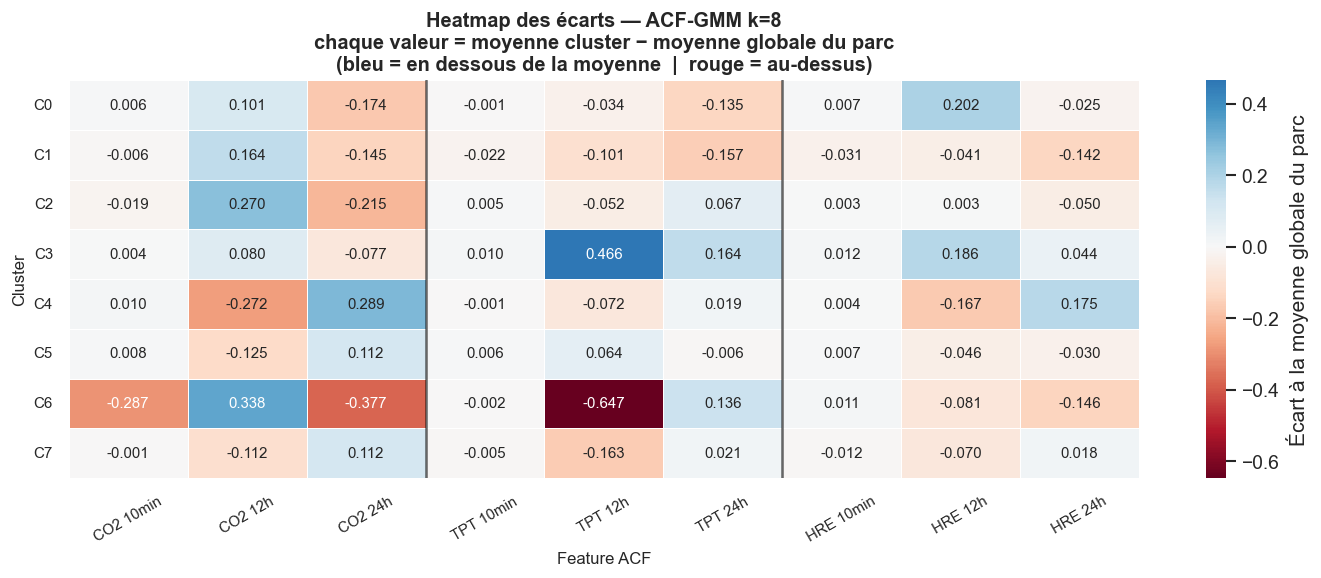

In [25]:
global_mean = df_acf_labeled[acf_cols].mean().rename(rename)
deviations  = means.subtract(global_mean, axis=1)
deviations.index = [f'C{c}' for c in deviations.index]

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    deviations,
    cmap='RdBu', center=0,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    linewidths=0.4, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Écart à la moyenne globale du parc'}
)

ax.set_title(
    f'Heatmap des écarts — ACF-GMM k={k_bic}\n'
    'chaque valeur = moyenne cluster − moyenne globale du parc\n'
    '(bleu = en dessous de la moyenne  |  rouge = au-dessus)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Feature ACF', fontsize=10)
ax.set_ylabel('Cluster', fontsize=10)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

# Ligne de séparation entre les 3 signaux
for sep in [3, 6]:
    ax.axvline(x=sep, color='black', lw=1.5, alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Clustering des journées (day-types) — validé par le semainier

Changement de granularité : au lieu de clusteriser les **logements** (~500 individus, structure faible — silhouette ≤ 0.18),
on clusterise les **journées** (~3 000 individus). Chaque journée = profil CO₂ 24h, **z-normé par logement**
(on compare des formes, pas des niveaux : 800 ppm dans un studio ≠ 800 ppm dans une maison).

Points clés établis sur les données :
- 95% des capteurs CO₂ sont en **chambre** → le signal mesure surtout l'occupation nocturne (sommeil) ;
- le **semainier** (présence déclarée par occupant, pas de 10 min, `IDN_PIECE=90` = extérieur) sert de **vérité terrain** ;
- chaque logement n'a que ~2 jours de week-end → la signature logement est construite sur les **jours de semaine** (≥ 3 jours).

In [ ]:
# Profils journaliers CO2 : 1 ligne = 1 journee de logement (24 valeurs horaires, z-norm par logement)
co2_e['DATE'] = co2_e['DATE_HEURE'].dt.normalize()

pts_jour       = co2_e.groupby(['CODELIEU', 'DATE']).size()
jours_complets = pts_jour[pts_jour >= 138].index   # >= 23h de couverture (138/144 points)

co2_j     = co2_e.set_index(['CODELIEU', 'DATE']).loc[jours_complets].reset_index()
stats_log = co2_j.groupby('CODELIEU')['VALEUR'].agg(['mean', 'std'])
co2_j     = co2_j.merge(stats_log, on='CODELIEU')
co2_j['z'] = (co2_j['VALEUR'] - co2_j['mean']) / co2_j['std']

prof_jour = co2_j.groupby(['CODELIEU', 'DATE', 'heure'])['z'].mean().unstack('heure').dropna()
X_jour    = prof_jour.values

print(f'Jours complets   : {len(jours_complets):,} / {len(pts_jour):,}')
print(f'Profils retenus  : {len(prof_jour):,} journées  ({prof_jour.index.get_level_values(0).nunique()} logements)')
print(f'Shape            : {X_jour.shape}  (journées x heures)')
display(prof_jour.head(3).round(2))

In [ ]:
# Choix de k : coude (inertie) + silhouette (separation) + stabilite par sous-echantillonnage (ARI)
from sklearn.metrics import adjusted_rand_score

rng = np.random.RandomState(0)
ks  = list(range(2, 21))
inerties, sils, stabs = [], [], []

for k in ks:
    km  = KMeans(n_clusters=k, random_state=42, n_init=30)
    lab = km.fit_predict(X_jour)
    inerties.append(km.inertia_)
    sils.append(silhouette_score(X_jour, lab, sample_size=2000, random_state=0))
    aris = []
    for _ in range(8):
        idx  = rng.choice(len(X_jour), int(0.8 * len(X_jour)), replace=False)
        lab2 = KMeans(n_clusters=k, random_state=rng.randint(10**6), n_init=30).fit_predict(X_jour[idx])
        aris.append(adjusted_rand_score(lab[idx], lab2))
    stabs.append(np.mean(aris))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(ks, inerties, 'o-', color='#C44E52', lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie intra-cluster')
axes[0].set_title('Coude', fontweight='bold')
axes[1].plot(ks, sils, 'bo-', lw=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Séparation', fontweight='bold')
axes[2].plot(ks, stabs, 'go-', lw=2)
axes[2].set_xlabel('k'); axes[2].set_ylabel('ARI (sous-échantillons 80%)')
axes[2].set_title('Stabilité', fontweight='bold')
for ax in axes:
    ax.axvline(6, color='grey', ls='--', lw=1, alpha=0.6)
    ax.grid(True, alpha=0.3)
plt.suptitle('K-Means sur les journées — choix de k  (pointillé : k=6 retenu)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

### Pourquoi k=6 et pas k=4 ?

Les courbes ci-dessus ne donnent pas de k « évident » : silhouette et stabilité décroissent de façon
quasi monotone (structure en continuum). Deux candidats se détachent : **k=4** (stabilité 0.91) et
**k=6**, petit rebond local (silhouette 0.161, stabilité 0.924 — meilleur que k=5 sur les deux critères).

On retient **k=6** pour trois raisons :

1. **Le passage k=4 → k=6 est emboîté** : chaque type de k=4 se subdivise proprement (pas de remélange).
   « Présence continue » se sépare en *présence diurne* (pic l'après-midi) et *pic du soir* ;
   « pic fin de nuit » se sépare en *pic du matin* (6-9h) et *pic nocturne intense* (3-6h).
2. **k=6 discrimine mieux la vérité terrain** : l'écart de présence diurne déclarée entre types passe
   de [34–50%] à [35–54%]. Le nouveau type « présence diurne » est le mieux validé (54% de présence
   déclarée en journée, record du parc — et 46% de jours de week-end).
3. **C'est la classe la plus utile pour la suite** : pour prédire l'activité des occupants, distinguer
   « quelqu'un est à la maison en journée » est précisément l'information cible — k=4 la noyait dans
   un type fourre-tout.

In [ ]:
# k=6 : rebond local de silhouette/stabilite + subdivisions interpretables (cf. markdown ci-dessus)
K_JOUR    = 6
km_jour   = KMeans(n_clusters=K_JOUR, random_state=42, n_init=30)
dt_labels = km_jour.fit_predict(X_jour)

# noms etablis a partir des profils moyens (valables pour random_state=42)
DT_NOMS = {0: 'Présence diurne',      # pic l'apres-midi, 46% WE
           1: 'Pic du soir',          # absence la journee, pic 21h
           2: 'Plat / absence',       # aucune accumulation
           3: 'Plateau nocturne',     # nuit haute, chute a 9h (actifs)
           4: 'Pic du matin',         # accumulation fin de nuit, pic 6-9h
           5: 'Pic nocturne intense'} # tres forte accumulation 3-6h

prof_dt = prof_jour.copy()
prof_dt['daytype'] = dt_labels
prof_dt['we']      = prof_dt.index.get_level_values('DATE').dayofweek >= 5

fig, ax = plt.subplots(figsize=(13, 6))
for c in range(K_JOUR):
    sub  = prof_dt[prof_dt['daytype'] == c]
    m    = sub[list(range(24))].mean()
    s    = sub[list(range(24))].std()
    line, = ax.plot(range(24), m, lw=2.2, marker='o', ms=3,
                    label=f'DT{c} — {DT_NOMS[c]}  (n={len(sub)}, {100*sub["we"].mean():.0f}% WE)')
    ax.fill_between(range(24), m - s, m + s, alpha=0.06, color=line.get_color())

ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.6)
ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('CO₂ (z-score du logement)')
ax.set_title('6 types de journées — profil CO₂ moyen ± 1σ\n'
             '(rappel : 28.6% des journées sont des jours de week-end)',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

In [ ]:
# Les formes de journees sont identiques semaine/week-end (r >= 0.86 par type) :
# ce qui change entre semaine et week-end, ce sont les PROPORTIONS de chaque type.
dist = (prof_dt.groupby('we')['daytype'].value_counts(normalize=True)
        .unstack('daytype') * 100)
dist.index = ['Semaine', 'Week-end']
dist.columns = [f'DT{c} {DT_NOMS[c]}' for c in dist.columns]

ax = dist.T.plot(kind='barh', figsize=(11, 5), width=0.75,
                 color=['#4C72B0', '#DD8452'])
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%', fontsize=9, padding=3)
ax.set_xlabel('Part des journées (%)')
ax.set_title('Répartition des types de journées — semaine vs week-end\n'
             'le week-end : moins de \u00ab plateau nocturne \u00bb (actifs), plus de grasse matinée et d\u2019absences',
             fontweight='bold')
ax.grid(True, alpha=0.25, axis='x')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [ ]:
# Validation par le semainier : presence declaree du menage, par type de journee
sem['present'] = sem['IDN_PIECE'].notna() & (sem['IDN_PIECE'] != 90)   # 90 = extérieur
sem['heure']   = (sem['CODE_HEURE'].str[2:].astype(int) - 1001) // 6   # V_1001..V_1144 -> heure 0..23

# taux de presence = moyenne sur les occupants, par logement x date x heure
pres_jour = sem.groupby(['CODELIEU', 'DATE', 'heure'])['present'].mean().unstack('heure')

common = prof_dt.index.intersection(pres_jour.index)
pres_c = pres_jour.loc[common]
lab_c  = prof_dt.loc[common, 'daytype']
print(f'Journées avec CO2 + semainier : {len(common):,}')

fig, ax = plt.subplots(figsize=(13, 5.5))
for c in range(K_JOUR):
    m = pres_c[lab_c == c].mean() * 100
    ax.plot(range(24), m, lw=2.2, marker='o', ms=3,
            label=f'DT{c} — {DT_NOMS[c]} (n={(lab_c == c).sum()})')

ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('Présence déclarée (%)')
ax.set_ylim(0, 100)
ax.set_title('Vérité terrain : présence déclarée (semainier) par type de journée\n'
             'si les courbes diffèrent → les day-types capturent bien l\'occupation',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

In [ ]:
# Signature logement = composition en day-types sur les JOURS DE SEMAINE (>= 3 jours)
# (2 jours de week-end seulement -> proportions quantifiees 0/50/100% = clusters artificiels)
semaine     = prof_dt[~prof_dt['we']].reset_index()
n_jours_sem = semaine.groupby('CODELIEU').size()
lieux_sig   = n_jours_sem[n_jours_sem >= 3].index

sig_log = (semaine[semaine['CODELIEU'].isin(lieux_sig)]
           .groupby('CODELIEU')['daytype']
           .value_counts(normalize=True).unstack(fill_value=0))
sig_log.columns = [f'dt{c}' for c in sig_log.columns]

K_LOG  = 4
cl_log = pd.Series(
    KMeans(n_clusters=K_LOG, random_state=42, n_init=30).fit_predict(sig_log.values),
    index=sig_log.index, name='cluster')

print(f'Signatures : {len(sig_log)} logements x {sig_log.shape[1]} dims')
compo = (sig_log.groupby(cl_log).mean() * 100).round(0)
compo.insert(0, 'n', cl_log.value_counts().sort_index())
compo.index = [f'C{c}' for c in compo.index]
display(
    compo.style
    .format({'n': '{:.0f}', **{c: '{:.0f}%' for c in sig_log.columns}})
    .background_gradient(subset=list(sig_log.columns), cmap='Blues', axis=None)
    .set_caption('Composition moyenne en day-types par cluster logement (jours de semaine)')
)

In [ ]:
# Validation des clusters logement : presence declaree en semaine + composition du menage
sem['we'] = sem['DATE'].dt.dayofweek >= 5
pres_log  = sem[~sem['we']].groupby(['CODELIEU', 'heure'])['present'].mean().unstack('heure')

common_l = cl_log.index.intersection(pres_log.index)

fig, ax = plt.subplots(figsize=(13, 5.5))
for c in range(K_LOG):
    sel = common_l[cl_log.loc[common_l] == c]
    m   = pres_log.loc[sel].mean() * 100
    dominant = sig_log.groupby(cl_log).mean().loc[c].idxmax()
    ax.plot(range(24), m, lw=2.2, marker='o', ms=3,
            label=f'C{c} (n={len(sel)}, dominé par {dominant.upper()})')

ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
ax.set_xlabel('Heure'); ax.set_ylabel('Présence déclarée (%)')
ax.set_ylim(0, 100)
ax.set_title('Présence déclarée en semaine, par cluster logement', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# caracteristiques du menage par cluster
infos_men = q_ind.groupby('CODELIEU').agg(
    n_occupants = ('NUM_OCCUPANT', 'nunique'),
    age_moyen   = ('AGE', 'mean'),
    n_enfants   = ('AGE', lambda s: (s < 18).sum()),
)
common_m = cl_log.index.intersection(infos_men.index)
tab = infos_men.loc[common_m].groupby(cl_log.loc[common_m]).mean().round(2)
tab.index = [f'C{c}' for c in tab.index]
display(tab.style.background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.2f}')
        .set_caption('Caractéristiques moyennes du ménage par cluster'))

### Bilan de la section 5

- Les **6 types de journées** sont robustes (stabilité ARI ≈ 0.92) et **validés par le semainier** :
  la présence diurne déclarée s'étale de 35% (« plateau nocturne ») à 54% (« présence diurne »),
  la présence nocturne de 73% (« plat/absence ») à 92% (« plateau nocturne »).
- La **signature logement** (composition en day-types, jours de semaine) donne 4 clusters logement stables
  (ARI ≈ 0.98, silhouette ≈ 0.37) : dominante « plateau nocturne » (actifs), dominante « pic du matin »,
  dominante « pic du soir », et un cluster mixte à dominante « absence ».
- **Limites** : le capteur CO₂ est en chambre (95% des cas) → on mesure surtout l'occupation de la chambre ;
  une seule semaine de mesure → la composition week-end (2 jours) est inexploitable telle quelle ;
  les types rares (« présence diurne », 6% des journées) ne dominent aucun cluster logement.
- **Suite logique** : le semainier fournit des labels de présence par créneau → base d'un futur **modèle supervisé**
  capteurs → présence (les features ACF de la section 4 et les day-types ci-dessus sont des entrées candidates).